# Formula 1 Race Outcome Prediction

## End-to-End Data Science and Machine Learning Notebook

This notebook is the main portfolio notebook for the **F1 Predictor** project.

The objective is to predict, for each driver and each Grand Prix:

- the probability of finishing in the **top 10**;
- the probability of finishing on the **podium**;
- the driver's **expected points**.

The project uses historical Kaggle Formula 1 data as the core dataset, extends the latest seasons with Jolpica-F1 snapshots, builds a driver-race table, creates leakage-safe rolling features, trains temporal machine learning models, evaluates them on a future season, and generates 2026 live/application predictions.

# Import Libraries

The notebook uses the same stack as the project code: `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`, `xgboost` when available, and the reusable modules under `src/`.

In [1]:
from pathlib import Path
import sys
import json
import warnings
import subprocess

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display, Image, Markdown
except ImportError:
    def display(obj):
        print(obj)

    def Markdown(text):
        return text

    class Image:
        def __init__(self, filename):
            self.filename = filename

        def __repr__(self):
            return f"Image(filename={self.filename!r})"

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

from src.config import load_config
from src.split import temporal_split
from src.modeling import select_feature_columns

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.05)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\bacht\Desktop\F1_Predictor


# Project Initialization

This section loads the project configuration and checks the expected directories. The goal is to make the notebook reproducible while keeping all paths centralized in `config.yaml`.

In [2]:
cfg = load_config(PROJECT_ROOT / "config.yaml")

paths = {
    "processed": cfg["resolved_paths"]["processed_data_dir"],
    "external": cfg["resolved_paths"]["external_data_dir"],
    "predictions": cfg["resolved_paths"]["predictions_dir"],
    "models": cfg["resolved_paths"]["models_dir"],
    "reports": cfg["resolved_paths"]["reports_dir"],
}

display(pd.DataFrame({
    "path_name": list(paths.keys()),
    "path": [str(p) for p in paths.values()],
    "exists": [p.exists() for p in paths.values()],
}))

,path_name,path,exists
0,processed,C:\Users\bacht\Desktop\F1_Predictor\data\proce...,True
1,external,C:\Users\bacht\Desktop\F1_Predictor\data\external,True
2,predictions,C:\Users\bacht\Desktop\F1_Predictor\data\predi...,True
3,models,C:\Users\bacht\Desktop\F1_Predictor\models,True
4,reports,C:\Users\bacht\Desktop\F1_Predictor\reports,True


In [3]:
print(json.dumps(cfg["data"], indent=2))
print(json.dumps(cfg["models"], indent=2))

{
  "min_season": 2014,
  "train_seasons": [
    2014,
    2023
  ],
  "validation_season": 2024,
  "test_season": 2025,
  "live_season": 2026,
  "kaggle_until_season": 2024,
  "use_jolpica_2025": true,
  "use_jolpica_2026": true,
  "use_2026_for_finetuning": false
}
{
  "retrain_after_jolpica_integration": true,
  "top10": {
    "type": "xgboost_classifier",
    "n_estimators": 500,
    "learning_rate": 0.03,
    "max_depth": 3,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "eval_metric": "logloss"
  },
  "podium": {
    "type": "xgboost_classifier",
    "n_estimators": 500,
    "learning_rate": 0.03,
    "max_depth": 3,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "eval_metric": "logloss",
    "auto_scale_pos_weight": true
  },
  "points": {
    "type": "xgboost_regressor",
    "n_estimators": 500,
    "learning_rate": 0.03,
    "max_depth": 3,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "objective": "reg:squarederror"
  }
}


# Optional Pipeline Execution

The cells below are intentionally disabled by default. The notebook is designed to inspect and explain the saved artifacts, but it can also rebuild the full pipeline when needed.

In [4]:
RUN_FULL_PIPELINE = False

if RUN_FULL_PIPELINE:
    commands = [
        [sys.executable, str(PROJECT_ROOT / "scripts" / "fetch_jolpica_data.py"), "--seasons", "2025", "2026"],
        [sys.executable, str(PROJECT_ROOT / "scripts" / "build_dataset.py")],
        [sys.executable, str(PROJECT_ROOT / "scripts" / "train_models.py")],
        [sys.executable, str(PROJECT_ROOT / "scripts" / "predict_2026.py")],
    ]
    for command in commands:
        print("Running:", " ".join(command))
        subprocess.run(command, check=True, cwd=PROJECT_ROOT)
else:
    print("Pipeline execution skipped. Set RUN_FULL_PIPELINE = True to rebuild all artifacts.")

Pipeline execution skipped. Set RUN_FULL_PIPELINE = True to rebuild all artifacts.


# Data Loading

The final modeling table should contain one row per driver-race. It combines Kaggle historical data and Jolpica snapshots for 2025 and 2026.

In [5]:
processed_dir = paths["processed"]

dataset_path = processed_dir / "f1_driver_race_dataset_with_jolpica.csv"
base_path = processed_dir / "base_driver_race_table_with_jolpica.csv"

if not dataset_path.exists():
    raise FileNotFoundError(f"Missing dataset: {dataset_path}")

df = pd.read_csv(dataset_path)
base_df = pd.read_csv(base_path) if base_path.exists() else pd.DataFrame()

print(f"Final dataset shape: {df.shape}")
print(f"Base table shape: {base_df.shape}")
display(df.head())

Final dataset shape: (5303, 96)
Base table shape: (5303, 32)


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,circuit_dnf_rate_before,grid_to_finish_delta,circuit_avg_grid_to_finish_delta_before,driver_points_share_before,constructor_points_share_before,driver_strength_rank_before,constructor_strength_rank_before,missing_driver_history,missing_constructor_history,missing_circuit_history
0,22148.0,900,1,131,44.0,1.0,NaN,R,19.0,0.0,...,NaN,18.0,NaN,NaN,NaN,1.0,1.0,1,1,1
1,22130.0,900,3,131,6.0,3.0,1.0,1,1.0,25.0,...,1.000000,-2.0,18.00,NaN,NaN,1.0,1.0,1,1,1
2,22133.0,900,4,6,14.0,5.0,4.0,4,4.0,12.0,...,0.500000,-1.0,8.00,NaN,NaN,1.0,1.0,1,1,1
3,22136.0,900,8,6,7.0,11.0,7.0,7,7.0,6.0,...,0.333333,-4.0,5.00,NaN,NaN,1.0,1.0,1,1,1
4,22149.0,900,13,3,19.0,9.0,NaN,R,20.0,0.0,...,0.250000,11.0,2.75,NaN,NaN,1.0,1.0,1,1,1


In [6]:
summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_values": df.isna().sum().values,
    "missing_rate": df.isna().mean().round(4).values,
    "unique_values": df.nunique(dropna=True).values,
})

display(summary.head(30))

,column,dtype,missing_values,missing_rate,unique_values
0,resultId,float64,677,0.1277,4626
1,raceId,int64,0,0.0000,261
2,driverId,int64,0,0.0000,63
3,constructorId,int64,0,0.0000,22
4,number,float64,0,0.0000,55
5,grid,float64,0,0.0000,23
6,position,float64,721,0.1360,22
7,positionText,object,0,0.0000,27
8,positionOrder,float64,0,0.0000,22
9,points,float64,0,0.0000,28


# Data Availability Audit

Before modeling, we verify which seasons are present, how many rows each season contains, and whether the driver-race key is unique.

,season,driver_race_rows
0,2014,407
1,2015,378
2,2016,462
3,2017,400
4,2018,420
5,2019,420
6,2020,340
7,2021,440
8,2022,440
9,2023,440


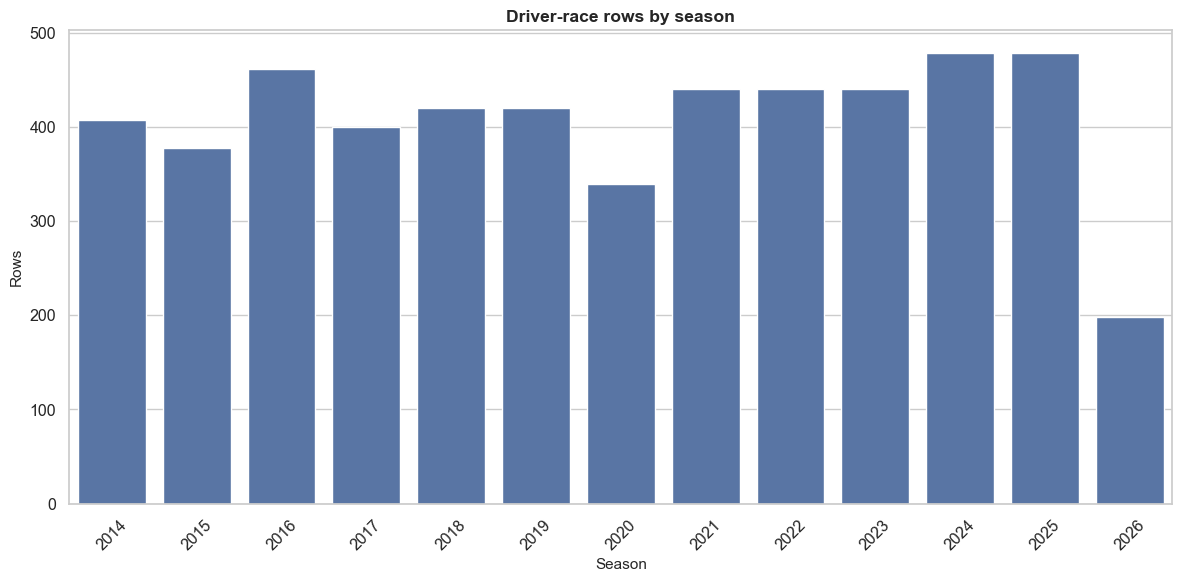

In [7]:
season_counts = (
    df.groupby("season")
    .size()
    .reset_index(name="driver_race_rows")
    .sort_values("season")
)

display(season_counts)

ax = sns.barplot(data=season_counts, x="season", y="driver_race_rows", color="#4C72B0")
ax.set_title("Driver-race rows by season")
ax.set_xlabel("Season")
ax.set_ylabel("Rows")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
key_columns = ["season", "round", "driverId"] if "driverId" in df.columns else ["season", "round", "driverRef"]
duplicate_count = df.duplicated(key_columns).sum()

print(f"Key columns: {key_columns}")
print(f"Duplicate driver-race rows: {duplicate_count}")

target_columns = ["target_top10", "target_podium", "target_points"]
display(df.groupby("season")[target_columns].apply(lambda x: x.isna().sum()))

Key columns: ['season', 'round', 'driverId']
Duplicate driver-race rows: 0


,target_top10,target_podium,target_points
season,,,
2014,0,0,0
2015,0,0,0
2016,0,0,0
2017,0,0,0
2018,0,0,0
2019,0,0,0
2020,0,0,0
2021,0,0,0
2022,0,0,0


# Jolpica Coverage Check

Jolpica is used for the official 2025 test season and the 2026 live/application layer. This section compares the available Jolpica snapshots with the final dataset.

In [9]:
jolpica_dir = paths["external"] / "jolpica"

coverage_rows = []
for season in [2025, 2026]:
    for table_name in ["schedule", "results", "qualifying", "driver_standings", "constructor_standings"]:
        path = jolpica_dir / f"jolpica_{season}_{table_name}.csv"
        if path.exists():
            tmp = pd.read_csv(path)
            rounds = pd.to_numeric(tmp.get("round"), errors="coerce").dropna().astype(int).nunique() if "round" in tmp else np.nan
            rows = len(tmp)
        else:
            rounds = np.nan
            rows = 0
        coverage_rows.append({"season": season, "snapshot": table_name, "rows": rows, "rounds": rounds})

jolpica_coverage = pd.DataFrame(coverage_rows)
display(jolpica_coverage)

,season,snapshot,rows,rounds
0,2025,schedule,24,24
1,2025,results,479,24
2,2025,qualifying,479,24
3,2025,driver_standings,21,1
4,2025,constructor_standings,10,1
5,2026,schedule,22,22
6,2026,results,198,9
7,2026,qualifying,195,9
8,2026,driver_standings,22,1
9,2026,constructor_standings,11,1


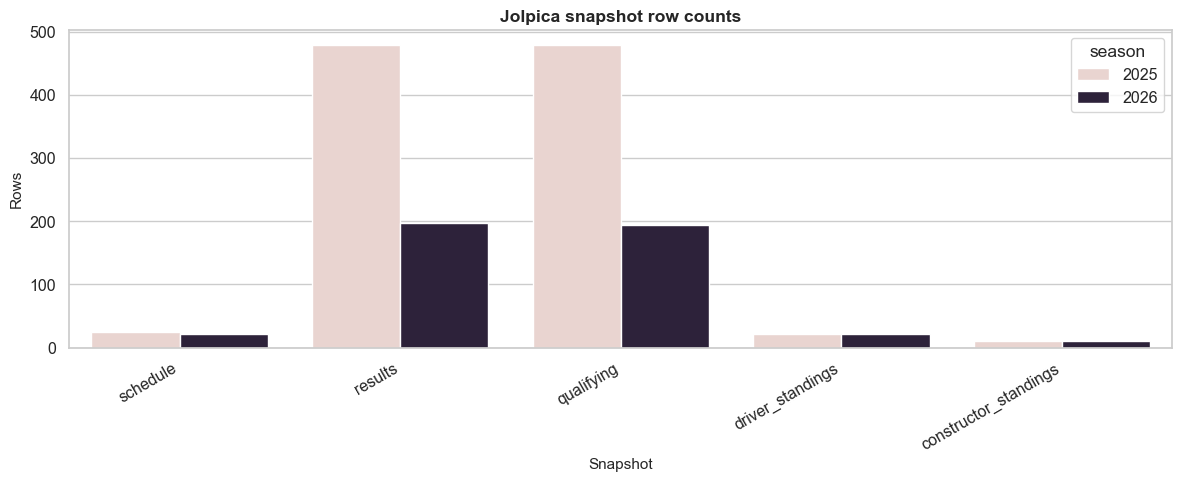

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=jolpica_coverage, x="snapshot", y="rows", hue="season", ax=ax)
ax.set_title("Jolpica snapshot row counts")
ax.set_xlabel("Snapshot")
ax.set_ylabel("Rows")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

,round,raceName,date,in_final_dataset
0,1,Australian Grand Prix,2026-03-08,True
1,2,Chinese Grand Prix,2026-03-15,True
2,3,Japanese Grand Prix,2026-03-29,True
3,4,Miami Grand Prix,2026-05-03,True
4,5,Canadian Grand Prix,2026-05-24,True
5,6,Monaco Grand Prix,2026-06-07,True
6,7,Barcelona Grand Prix,2026-06-14,True
7,8,Austrian Grand Prix,2026-06-28,True
8,9,British Grand Prix,2026-07-05,True
9,10,Belgian Grand Prix,2026-07-19,False


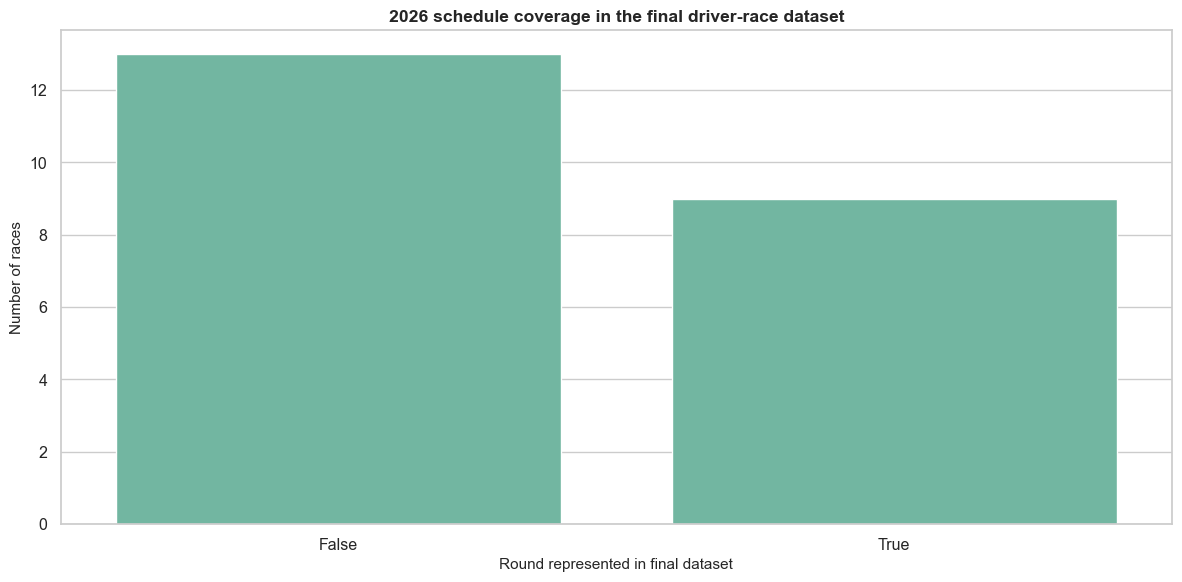

In [11]:
schedule_2026_path = jolpica_dir / "jolpica_2026_schedule.csv"
if schedule_2026_path.exists():
    schedule_2026 = pd.read_csv(schedule_2026_path)
    dataset_2026_rounds = set(df.loc[df["season"].eq(2026), "round"].dropna().astype(int))
    schedule_2026["in_final_dataset"] = schedule_2026["round"].astype(int).isin(dataset_2026_rounds)
    display(schedule_2026[["round", "raceName", "date", "in_final_dataset"]])

    ax = sns.countplot(data=schedule_2026, x="in_final_dataset")
    ax.set_title("2026 schedule coverage in the final driver-race dataset")
    ax.set_xlabel("Round represented in final dataset")
    ax.set_ylabel("Number of races")
    plt.tight_layout()
    plt.show()

# Exploratory Data Analysis

The following charts explain the raw modeling problem: how results, points, grids, constructors, drivers, and circuits are distributed across the dataset.

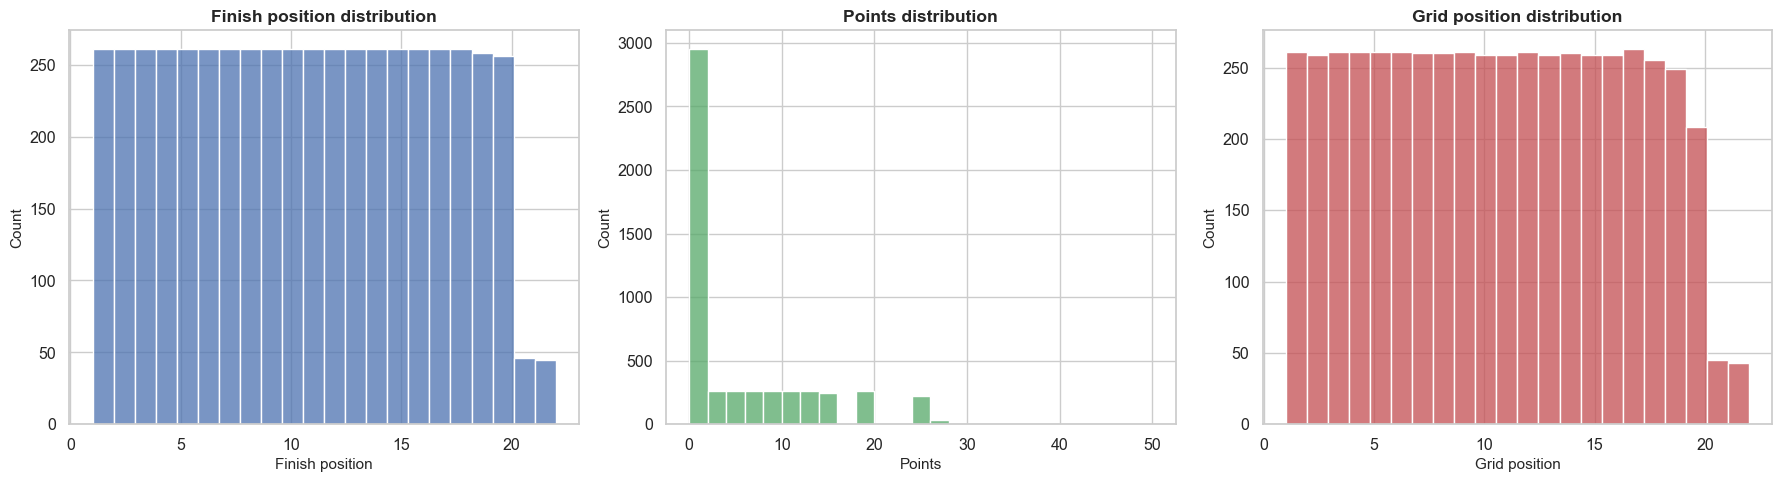

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df["positionOrder"].dropna(), bins=22, kde=False, ax=axes[0], color="#4C72B0")
axes[0].set_title("Finish position distribution")
axes[0].set_xlabel("Finish position")

sns.histplot(df["points"].dropna(), bins=25, kde=False, ax=axes[1], color="#55A868")
axes[1].set_title("Points distribution")
axes[1].set_xlabel("Points")

sns.histplot(df["grid_position"].dropna(), bins=22, kde=False, ax=axes[2], color="#C44E52")
axes[2].set_title("Grid position distribution")
axes[2].set_xlabel("Grid position")

plt.tight_layout()
plt.show()

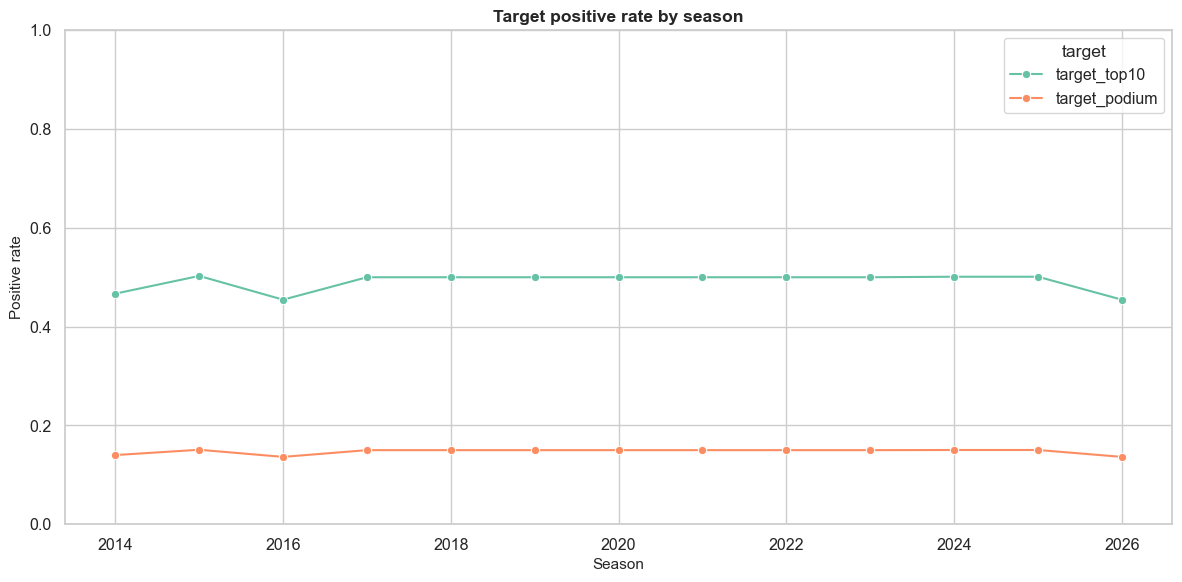

In [13]:
target_rates = (
    df.groupby("season")[["target_top10", "target_podium"]]
    .mean()
    .reset_index()
    .melt(id_vars="season", var_name="target", value_name="positive_rate")
)

ax = sns.lineplot(data=target_rates, x="season", y="positive_rate", hue="target", marker="o")
ax.set_title("Target positive rate by season")
ax.set_xlabel("Season")
ax.set_ylabel("Positive rate")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

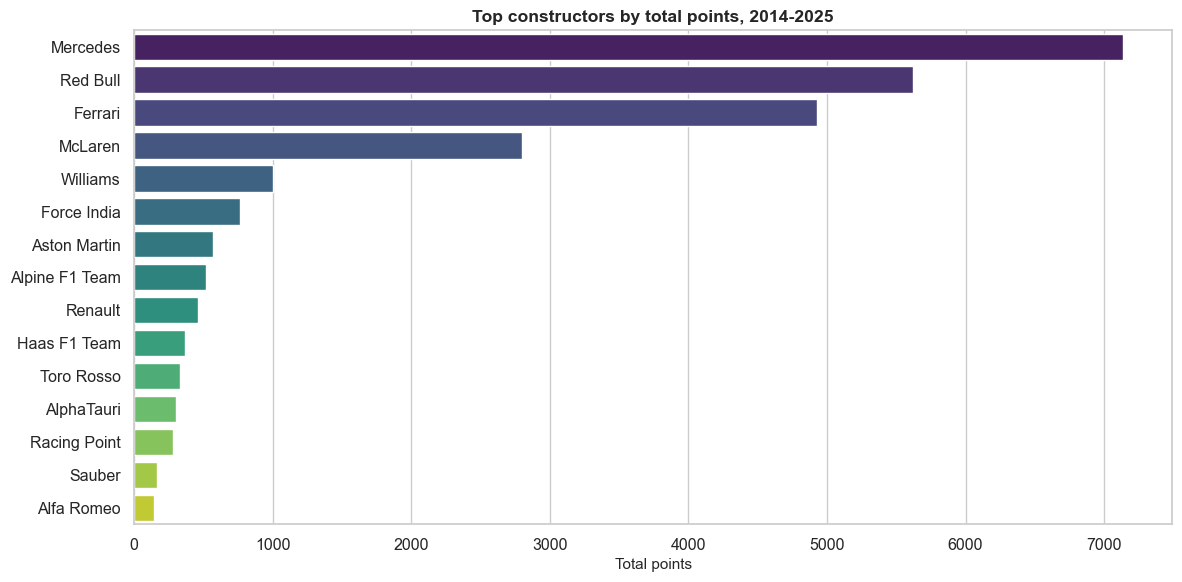

In [14]:
constructor_points = (
    df[df["season"].between(2014, 2025)]
    .groupby("constructor_name")["points"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

ax = sns.barplot(data=constructor_points, y="constructor_name", x="points", palette="viridis")
ax.set_title("Top constructors by total points, 2014-2025")
ax.set_xlabel("Total points")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

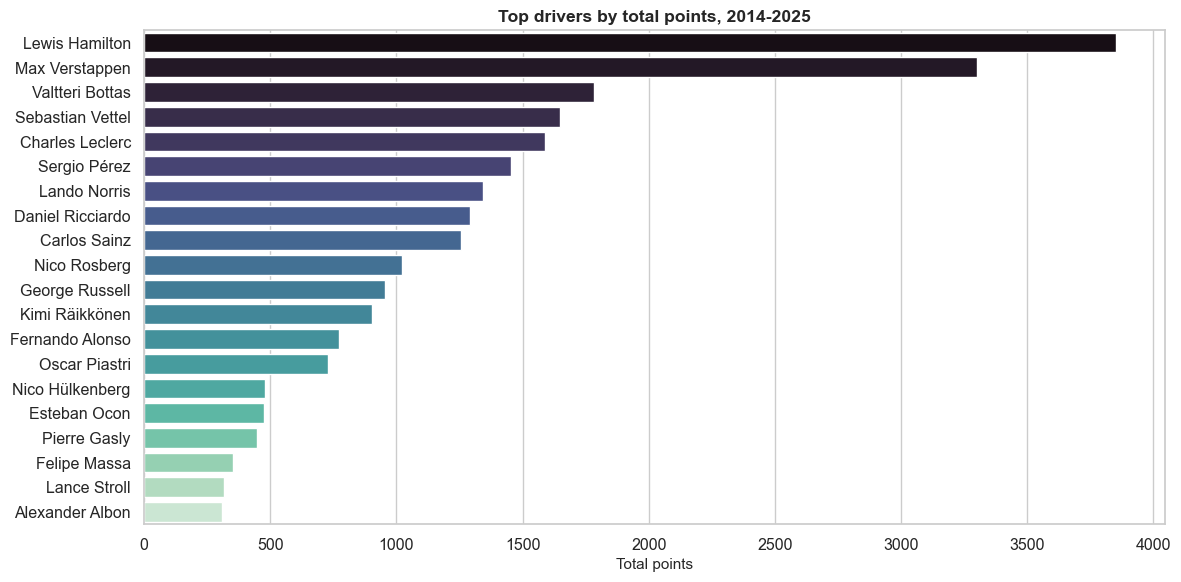

In [15]:
driver_points = (
    df[df["season"].between(2014, 2025)]
    .groupby("driver_name")["points"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)

ax = sns.barplot(data=driver_points, y="driver_name", x="points", palette="mako")
ax.set_title("Top drivers by total points, 2014-2025")
ax.set_xlabel("Total points")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

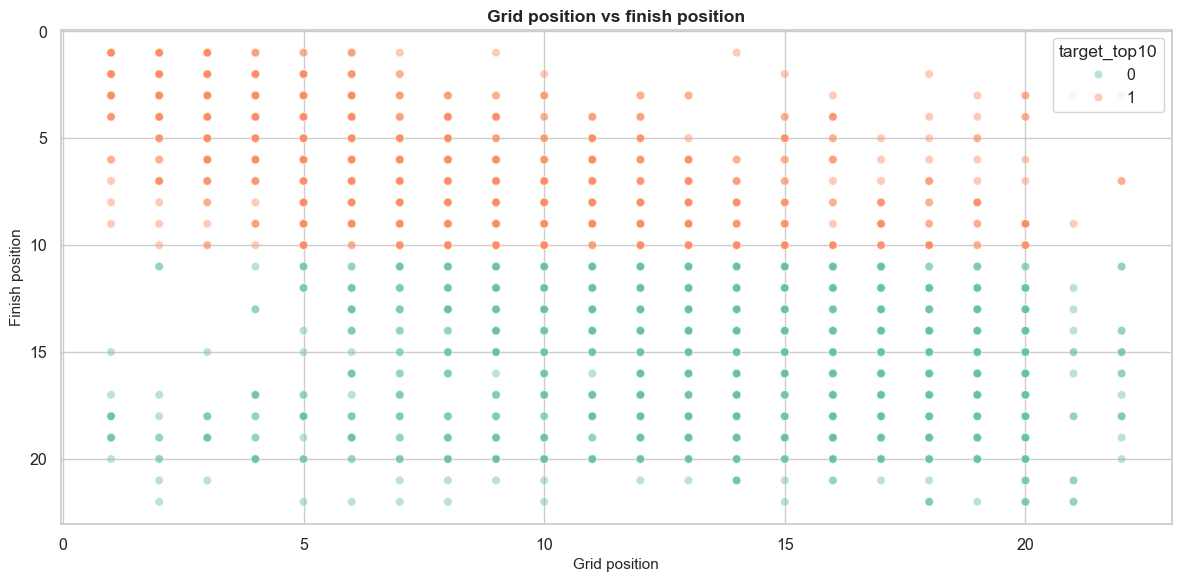

In [16]:
grid_finish = df.dropna(subset=["grid_position", "positionOrder"]).copy()
grid_finish = grid_finish[grid_finish["season"].between(2014, 2025)]

ax = sns.scatterplot(
    data=grid_finish.sample(min(2500, len(grid_finish)), random_state=42),
    x="grid_position",
    y="positionOrder",
    hue="target_top10",
    alpha=0.45,
)
ax.set_title("Grid position vs finish position")
ax.set_xlabel("Grid position")
ax.set_ylabel("Finish position")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

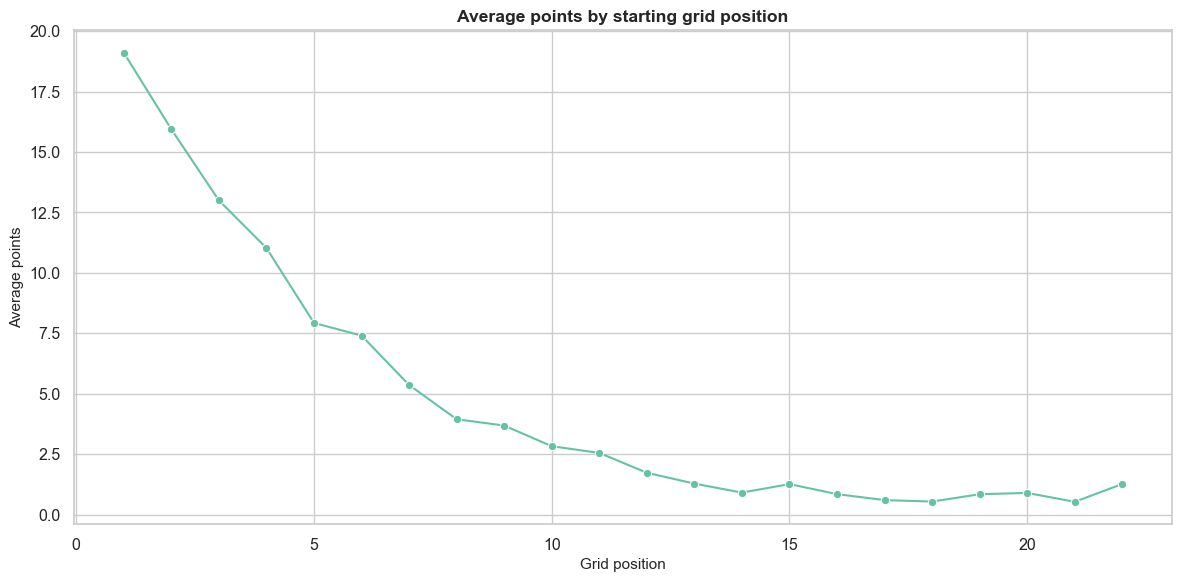

In [17]:
avg_points_by_grid = (
    df[df["season"].between(2014, 2025)]
    .dropna(subset=["grid_position"])
    .groupby("grid_position")["points"]
    .mean()
    .reset_index()
)

ax = sns.lineplot(data=avg_points_by_grid, x="grid_position", y="points", marker="o")
ax.set_title("Average points by starting grid position")
ax.set_xlabel("Grid position")
ax.set_ylabel("Average points")
plt.tight_layout()
plt.show()

In [18]:
circuit_profile = (
    df[df["season"].between(2014, 2025)]
    .groupby("raceName")
    .agg(
        avg_points=("points", "mean"),
        podium_rate=("target_podium", "mean"),
        top10_rate=("target_top10", "mean"),
        races=("round", "count"),
    )
    .sort_values("avg_points", ascending=False)
    .head(15)
    .reset_index()
)

display(circuit_profile)

,raceName,avg_points,podium_rate,top10_rate,races
0,Abu Dhabi Grand Prix,5.446281,0.14876,0.495868,242
1,70th Anniversary Grand Prix,5.100000,0.15000,0.500000,20
2,Tuscan Grand Prix,5.100000,0.15000,0.500000,20
3,Portuguese Grand Prix,5.100000,0.15000,0.500000,40
4,Turkish Grand Prix,5.100000,0.15000,0.500000,40
5,Eifel Grand Prix,5.100000,0.15000,0.500000,20
6,Styrian Grand Prix,5.100000,0.15000,0.500000,40
7,Sakhir Grand Prix,5.100000,0.15000,0.500000,20
8,Emilia Romagna Grand Prix,5.090000,0.15000,0.500000,100
9,Dutch Grand Prix,5.090000,0.15000,0.500000,100


# Data Quality and Missing Values

The model intentionally keeps missingness indicators for cold starts and limited history. We still inspect missing values to understand where imputations will happen.

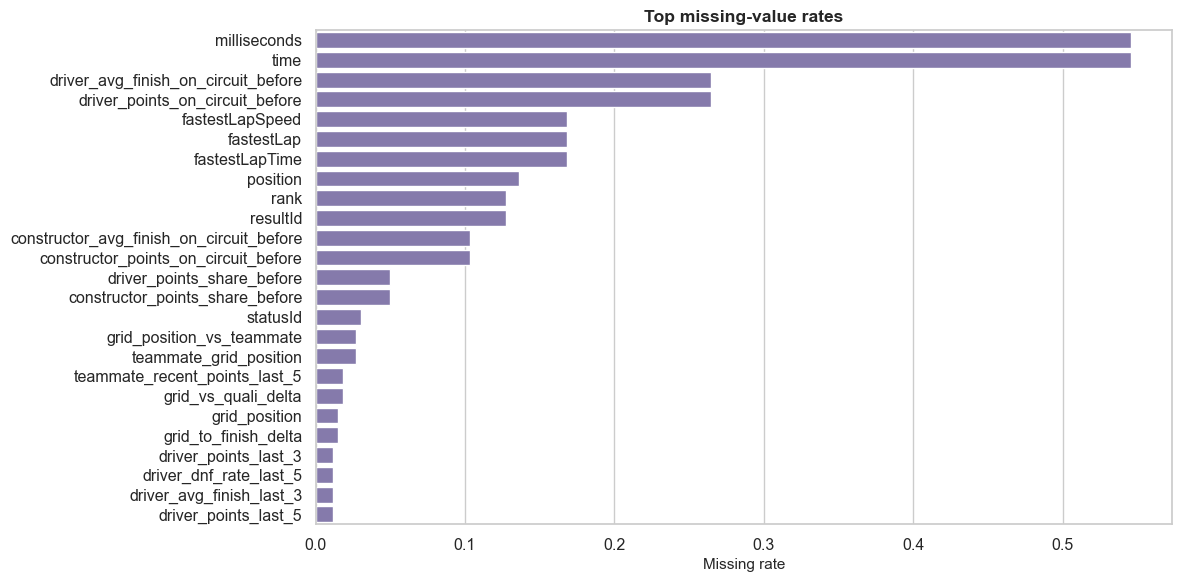

In [19]:
missing_profile = (
    df.isna()
    .mean()
    .sort_values(ascending=False)
    .head(25)
    .reset_index()
)
missing_profile.columns = ["column", "missing_rate"]

ax = sns.barplot(data=missing_profile, y="column", x="missing_rate", color="#8172B3")
ax.set_title("Top missing-value rates")
ax.set_xlabel("Missing rate")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

# Feature Engineering

The central modeling rule is simple: **a feature may use current grid/qualifying information or past race information, but never the current race result**.

Rolling features such as `driver_avg_finish_last_5` and `constructor_points_last_5` are computed with `shift(1)` before the rolling window. This prevents the current race from leaking into its own prediction.

In [20]:
feature_groups = {
    "Grid and qualifying": ["grid", "grid_position", "quali_position", "grid_vs_quali_delta", "qualified_top10", "started_top10"],
    "Driver rolling form": [c for c in df.columns if c.startswith("driver_") and ("last_" in c or "before" in c)],
    "Constructor rolling form": [c for c in df.columns if c.startswith("constructor_") and ("last_" in c or "before" in c)],
    "Teammate features": [c for c in df.columns if c.startswith("teammate_") or c.endswith("_vs_teammate")],
    "Circuit history": [c for c in df.columns if c.startswith("circuit_")],
    "Missingness flags": [c for c in df.columns if c.startswith("missing_")],
}

for group, columns in feature_groups.items():
    print(f"\n{group} ({len(columns)} columns)")
    print(columns[:20])


Grid and qualifying (6 columns)
['grid', 'grid_position', 'quali_position', 'grid_vs_quali_delta', 'qualified_top10', 'started_top10']

Driver rolling form (20 columns)
['driver_races_before', 'driver_avg_finish_last_3', 'driver_points_last_3', 'driver_avg_finish_last_5', 'driver_points_last_5', 'driver_top10_rate_last_5', 'driver_podium_rate_last_5', 'driver_dnf_rate_last_5', 'driver_avg_finish_last_10', 'driver_points_last_10', 'driver_top10_rate_last_10', 'driver_podium_rate_last_10', 'driver_dnf_rate_last_10', 'driver_avg_grid_last_5', 'driver_avg_quali_last_5', 'driver_points_before_season', 'driver_avg_finish_on_circuit_before', 'driver_points_on_circuit_before', 'driver_points_share_before', 'driver_strength_rank_before']

Constructor rolling form (20 columns)
['constructor_races_before', 'constructor_avg_finish_last_3', 'constructor_points_last_3', 'constructor_avg_finish_last_5', 'constructor_points_last_5', 'constructor_top10_rate_last_5', 'constructor_podium_rate_last_5', '

In [21]:
selected_features = select_feature_columns(df)
print(f"Selected model features: {len(selected_features)}")
display(pd.DataFrame({"feature": selected_features}).head(80))

Selected model features: 65


,feature
0,circuit_avg_grid_to_finish_delta_before
1,circuit_dnf_rate_before
2,constructor_avg_finish_last_10
3,constructor_avg_finish_last_3
4,constructor_avg_finish_last_5
...,...
60,started_top10
61,started_top3
62,teammate_grid_position
63,teammate_quali_position


In [22]:
feature_presence = pd.DataFrame({
    "feature": selected_features,
    "missing_rate": df[selected_features].isna().mean().values,
    "std": df[selected_features].std(numeric_only=True).values,
}).sort_values("missing_rate", ascending=False)

display(feature_presence.head(20))

,feature,missing_rate,std
25,driver_avg_finish_on_circuit_before,0.264567,4.418518
36,driver_points_on_circuit_before,0.264567,33.501057
16,constructor_points_on_circuit_before,0.103526,74.658780
5,constructor_avg_finish_on_circuit_before,0.103526,4.240226
37,driver_points_share_before,0.049783,0.296652
17,constructor_points_share_before,0.049783,0.327904
62,teammate_grid_position,0.027343,5.840196
44,grid_position_vs_teammate,0.027343,5.236171
64,teammate_recent_points_last_5,0.018669,29.547154
45,grid_vs_quali_delta,0.018292,1.582557


### Rolling-feature example: Alexander Albon

,season,round,raceName,positionOrder,points,driver_avg_finish_last_5,driver_points_last_5,driver_top10_rate_last_10
4936,2025,16,Italian Grand Prix,7.0,6.0,10.2,22.0,0.6
4956,2025,17,Azerbaijan Grand Prix,13.0,0.0,8.2,28.0,0.6
4976,2025,18,Singapore Grand Prix,14.0,0.0,9.2,24.0,0.5
4996,2025,19,United States Grand Prix,14.0,0.0,10.8,16.0,0.4
5016,2025,20,Mexico City Grand Prix,12.0,0.0,10.6,16.0,0.4
5036,2025,21,São Paulo Grand Prix,11.0,0.0,12.0,6.0,0.4
5056,2025,22,Las Vegas Grand Prix,16.0,0.0,12.8,0.0,0.4
5076,2025,23,Qatar Grand Prix,11.0,0.0,13.4,0.0,0.3
5096,2025,24,Abu Dhabi Grand Prix,16.0,0.0,12.8,0.0,0.2
5118,2026,1,Australian Grand Prix,12.0,0.0,13.2,0.0,0.2


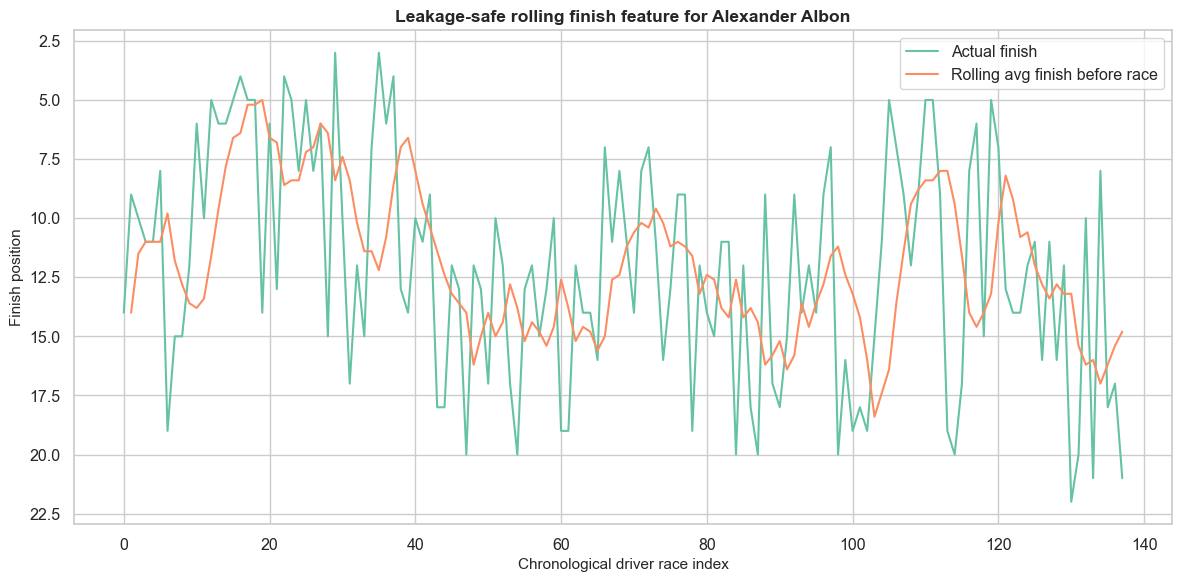

In [23]:
example_driver = (
    df[df["season"].between(2023, 2026)]
    .groupby("driver_name")
    .size()
    .sort_values(ascending=False)
    .index[0]
)

driver_timeline = df[df["driver_name"].eq(example_driver)].sort_values(["season", "round"]).copy()

cols_to_show = [
    "season", "round", "raceName", "positionOrder", "points",
    "driver_avg_finish_last_5", "driver_points_last_5", "driver_top10_rate_last_10"
]

display(Markdown(f"### Rolling-feature example: {example_driver}"))
display(driver_timeline[cols_to_show].tail(18))

ax = sns.lineplot(data=driver_timeline, x=np.arange(len(driver_timeline)), y="positionOrder", label="Actual finish")
sns.lineplot(data=driver_timeline, x=np.arange(len(driver_timeline)), y="driver_avg_finish_last_5", label="Rolling avg finish before race", ax=ax)
ax.set_title(f"Leakage-safe rolling finish feature for {example_driver}")
ax.set_xlabel("Chronological driver race index")
ax.set_ylabel("Finish position")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

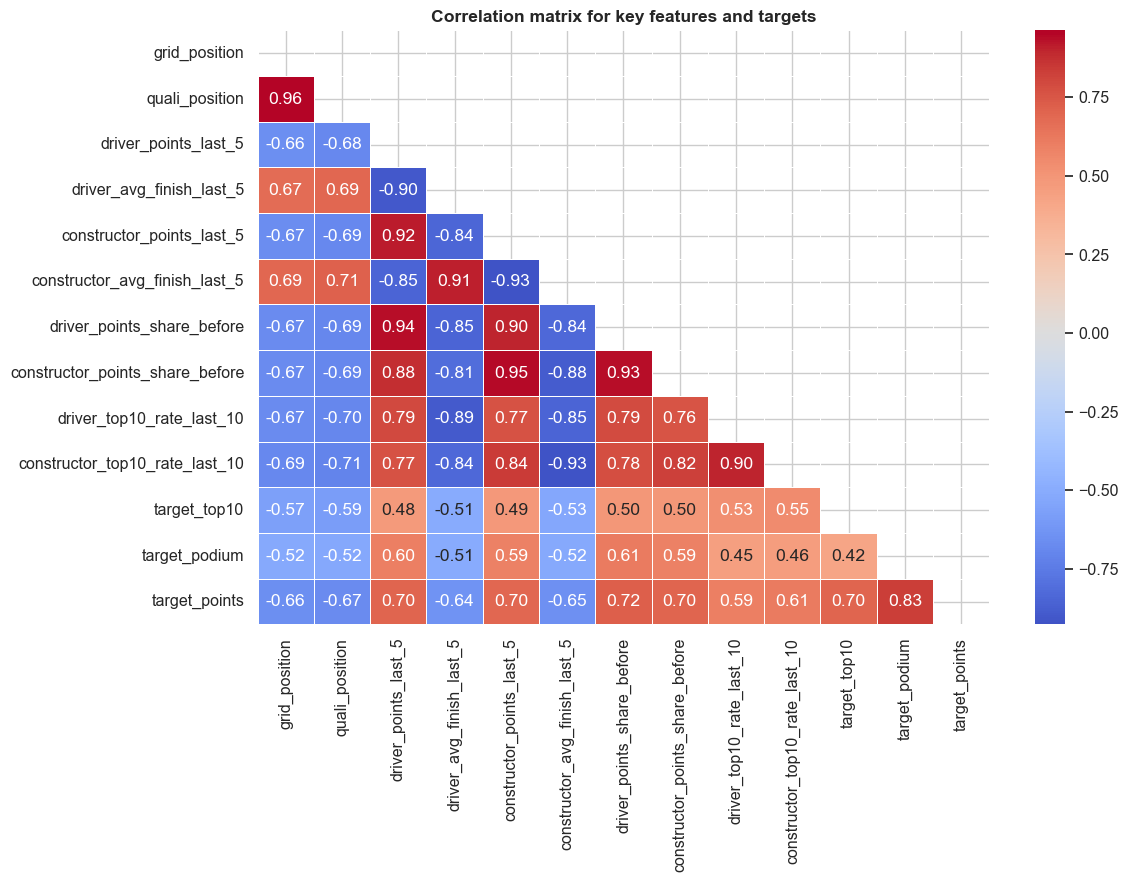

In [24]:
important_feature_candidates = [
    "grid_position",
    "quali_position",
    "driver_points_last_5",
    "driver_avg_finish_last_5",
    "constructor_points_last_5",
    "constructor_avg_finish_last_5",
    "driver_points_share_before",
    "constructor_points_share_before",
    "driver_top10_rate_last_10",
    "constructor_top10_rate_last_10",
]
available_corr_features = [c for c in important_feature_candidates if c in df.columns]
corr_cols = available_corr_features + ["target_top10", "target_podium", "target_points"]

corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 9))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation matrix for key features and targets")
plt.tight_layout()
plt.show()

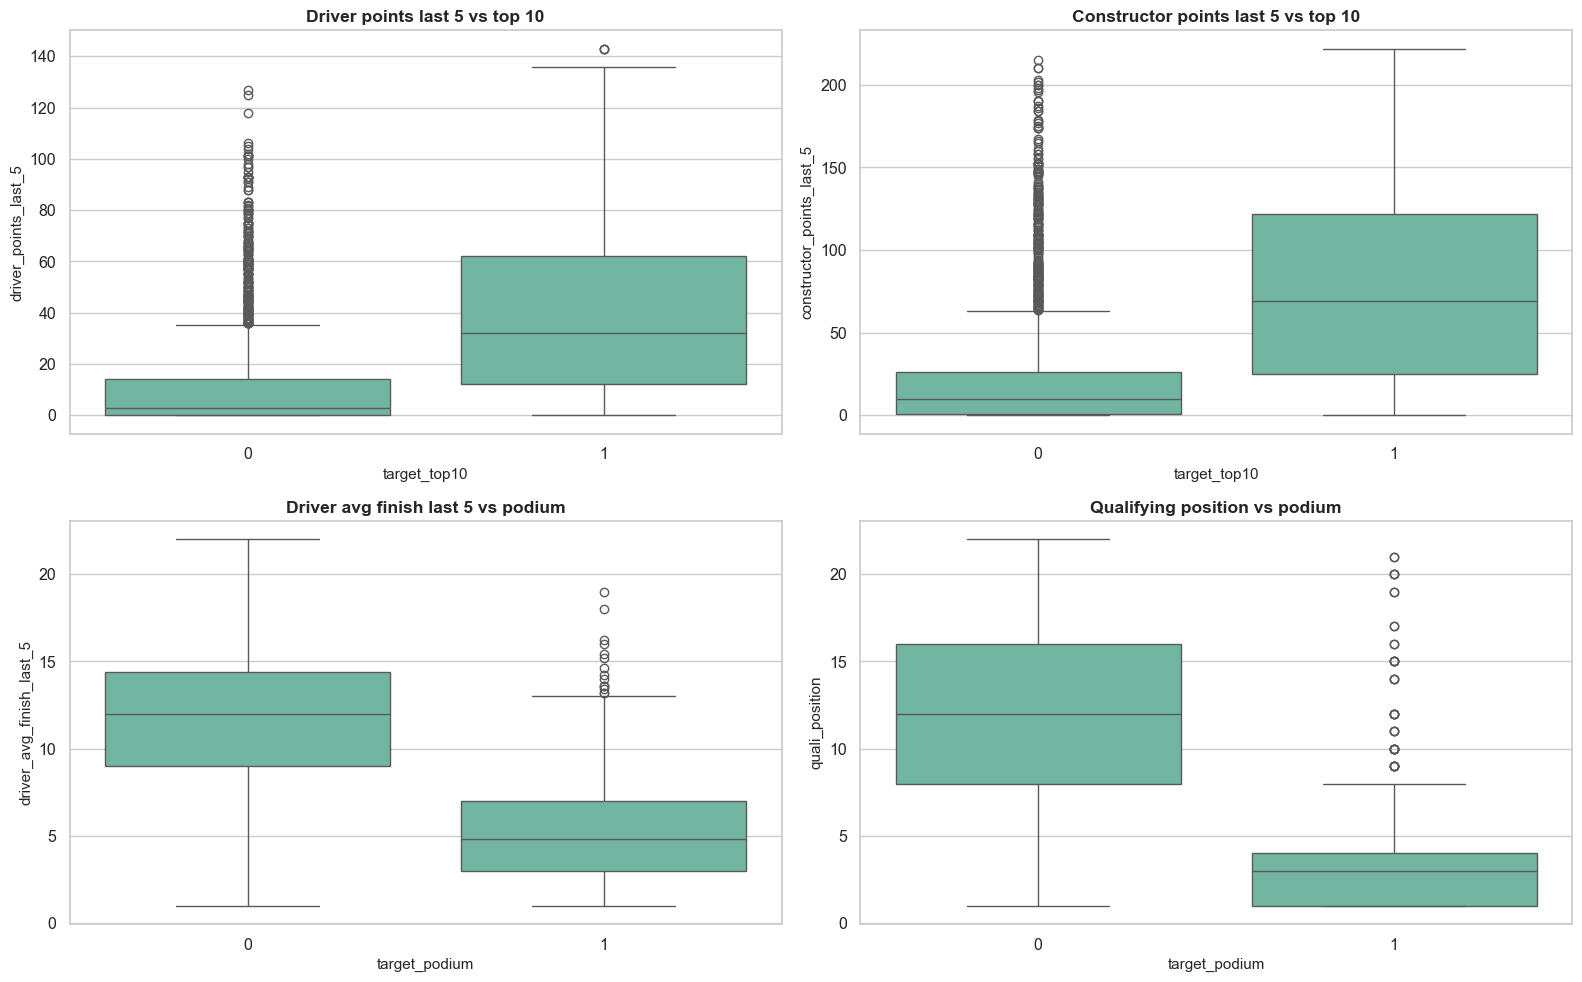

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

plot_specs = [
    ("driver_points_last_5", "target_top10", "Driver points last 5 vs top 10"),
    ("constructor_points_last_5", "target_top10", "Constructor points last 5 vs top 10"),
    ("driver_avg_finish_last_5", "target_podium", "Driver avg finish last 5 vs podium"),
    ("quali_position", "target_podium", "Qualifying position vs podium"),
]

for ax, (feature, target, title) in zip(axes.ravel(), plot_specs):
    if feature in df.columns:
        sns.boxplot(data=df[df["season"].between(2014, 2025)], x=target, y=feature, ax=ax)
        ax.set_title(title)
        ax.set_xlabel(target)
        ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

# Temporal Split

The project uses a chronological split:

- train: 2014-2023
- validation: 2024
- official test: 2025
- live/application: 2026

This avoids random train-test leakage across time.

,split,rows,min_season,max_season,n_seasons
0,train,4147,2014,2023,10
1,validation,479,2024,2024,1
2,test,479,2025,2025,1
3,live,198,2026,2026,1


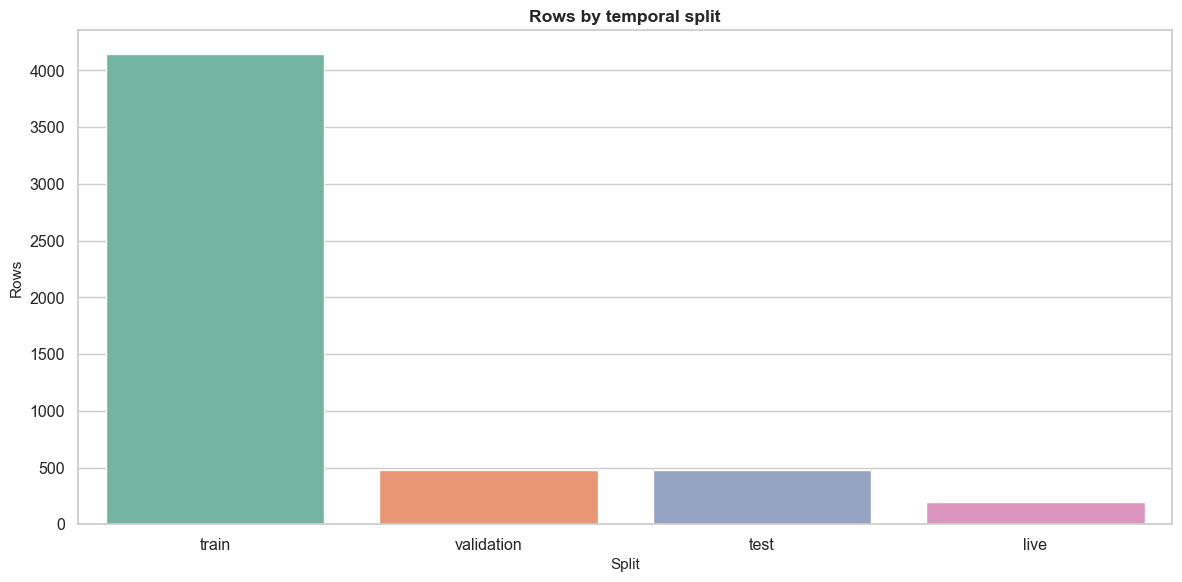

In [26]:
parts = temporal_split(df, cfg)

split_summary = []
for split_name, split_df in parts.items():
    split_summary.append({
        "split": split_name,
        "rows": len(split_df),
        "min_season": int(split_df["season"].min()) if len(split_df) else None,
        "max_season": int(split_df["season"].max()) if len(split_df) else None,
        "n_seasons": split_df["season"].nunique(),
    })

split_summary = pd.DataFrame(split_summary)
display(split_summary)

ax = sns.barplot(data=split_summary, x="split", y="rows", palette="Set2")
ax.set_title("Rows by temporal split")
ax.set_xlabel("Split")
ax.set_ylabel("Rows")
plt.tight_layout()
plt.show()

In [27]:
split_target_rates = []
for split_name, split_df in parts.items():
    split_target_rates.append({
        "split": split_name,
        "top10_rate": split_df["target_top10"].mean(),
        "podium_rate": split_df["target_podium"].mean(),
        "avg_points": split_df["target_points"].mean(),
    })

split_target_rates = pd.DataFrame(split_target_rates)
display(split_target_rates)

,split,top10_rate,podium_rate,avg_points
0,train,0.491922,0.147577,5.003255
1,validation,0.501044,0.150313,5.100209
2,test,0.501044,0.150313,5.060543
3,live,0.454545,0.136364,4.590909


# Model Training Artifacts

The project trains:

- an XGBoost classifier for top 10;
- an XGBoost classifier for podium, with class imbalance handling;
- an XGBoost regressor for expected points.

If XGBoost is unavailable, the project code falls back to Random Forest models.

In [28]:
model_dir = paths["models"]
model_paths = {
    "top10": model_dir / "top10_model.pkl",
    "podium": model_dir / "podium_model.pkl",
    "points": model_dir / "points_model.pkl",
    "preprocessor": model_dir / "preprocessing_pipeline.pkl",
    "feature_columns": model_dir / "feature_columns.json",
}

artifact_table = pd.DataFrame({
    "artifact": model_paths.keys(),
    "path": [str(p) for p in model_paths.values()],
    "exists": [p.exists() for p in model_paths.values()],
})
display(artifact_table)

,artifact,path,exists
0,top10,C:\Users\bacht\Desktop\F1_Predictor\models\top...,True
1,podium,C:\Users\bacht\Desktop\F1_Predictor\models\pod...,True
2,points,C:\Users\bacht\Desktop\F1_Predictor\models\poi...,True
3,preprocessor,C:\Users\bacht\Desktop\F1_Predictor\models\pre...,True
4,feature_columns,C:\Users\bacht\Desktop\F1_Predictor\models\fea...,True


In [29]:
models = {}
for name in ["top10", "podium", "points"]:
    if model_paths[name].exists():
        models[name] = joblib.load(model_paths[name])

saved_features = json.loads(model_paths["feature_columns"].read_text(encoding="utf-8")) if model_paths["feature_columns"].exists() else []

for name, model in models.items():
    print(f"{name}: {type(model)}")
    if hasattr(model, "get_params"):
        params = model.get_params()
        display(pd.Series({
            "n_estimators": params.get("n_estimators"),
            "learning_rate": params.get("learning_rate"),
            "max_depth": params.get("max_depth"),
            "scale_pos_weight": params.get("scale_pos_weight"),
            "objective": params.get("objective"),
        }).to_frame("value"))

print(f"Saved feature columns: {len(saved_features)}")

top10: <class 'xgboost.sklearn.XGBClassifier'>


,value
n_estimators,500
learning_rate,0.03
max_depth,3
scale_pos_weight,None
objective,binary:logistic


podium: <class 'xgboost.sklearn.XGBClassifier'>


,value
n_estimators,500
learning_rate,0.03
max_depth,3
scale_pos_weight,5.776144
objective,binary:logistic


points: <class 'xgboost.sklearn.XGBRegressor'>


,value
n_estimators,500
learning_rate,0.03
max_depth,3
scale_pos_weight,None
objective,reg:squarederror


Saved feature columns: 65


# Evaluation Metrics

This section loads the saved metrics from `reports/metrics/` and visualizes model performance on validation 2024 and official test 2025.

In [30]:
metrics_dir = paths["reports"] / "metrics"

def load_json(path):
    return json.loads(path.read_text(encoding="utf-8")) if path.exists() else {}

top10_metrics = load_json(metrics_dir / "top10_metrics.json")
podium_metrics = load_json(metrics_dir / "podium_metrics.json")
points_metrics = load_json(metrics_dir / "points_metrics.json")
baseline_metrics = load_json(metrics_dir / "baseline_metrics.json")

display(Markdown("## Top 10 metrics"))
display(pd.DataFrame(top10_metrics).T)

display(Markdown("## Podium metrics"))
display(pd.DataFrame(podium_metrics).T)

display(Markdown("## Points metrics"))
display(pd.DataFrame(points_metrics).T)

## Top 10 metrics

,accuracy,precision,recall,f1,average_precision,brier_score,confusion_matrix,roc_auc
validation,0.837161,0.831967,0.845833,0.838843,0.895117,0.121011,"[[198, 41], [37, 203]]",0.908978
test,0.762004,0.756098,0.775,0.765432,0.820641,0.165875,"[[179, 60], [54, 186]]",0.834641


## Podium metrics

,accuracy,precision,recall,f1,average_precision,brier_score,confusion_matrix,roc_auc
validation,0.874739,0.552632,0.875,0.677419,0.639478,0.093013,"[[356, 51], [9, 63]]",0.925949
test,0.891441,0.590909,0.902778,0.714286,0.734196,0.080931,"[[362, 45], [7, 65]]",0.942636


## Points metrics

,mae,rmse,r2,spearman
validation,2.592831,4.270141,0.650623,0.793488
test,2.919344,4.499972,0.606813,0.704022


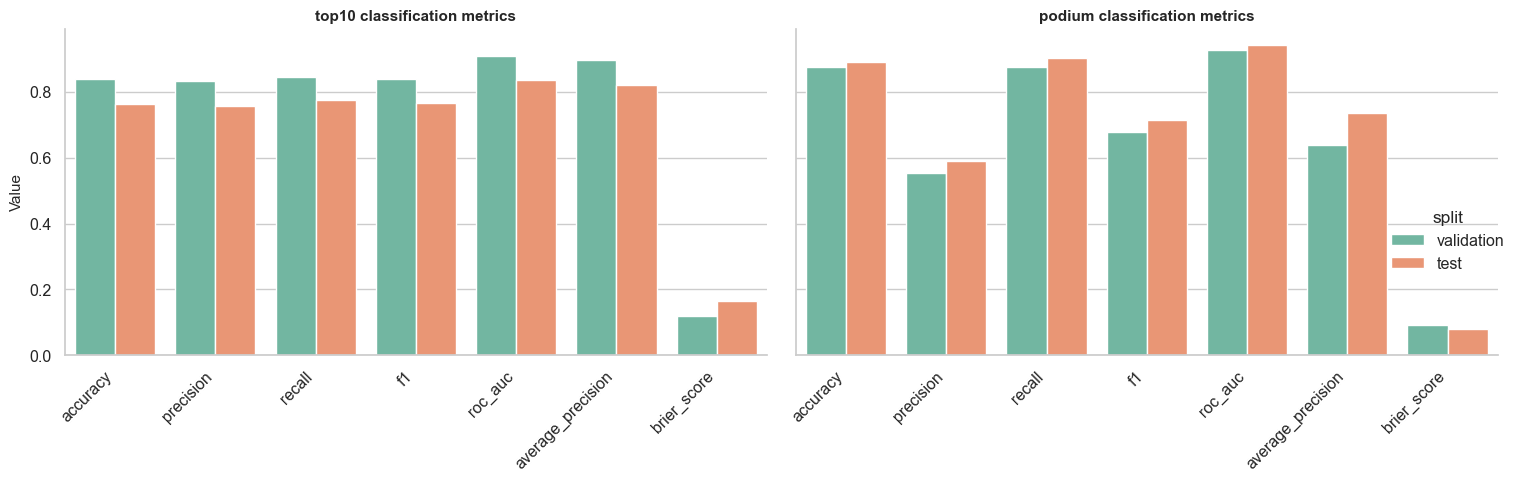

In [31]:
classification_records = []
for task_name, metric_dict in [("top10", top10_metrics), ("podium", podium_metrics)]:
    for split_name, values in metric_dict.items():
        for metric_name in ["accuracy", "precision", "recall", "f1", "roc_auc", "average_precision", "brier_score"]:
            classification_records.append({
                "task": task_name,
                "split": split_name,
                "metric": metric_name,
                "value": values.get(metric_name),
            })

classification_metric_df = pd.DataFrame(classification_records)

g = sns.catplot(
    data=classification_metric_df,
    x="metric",
    y="value",
    hue="split",
    col="task",
    kind="bar",
    height=5,
    aspect=1.4,
)
g.set_xticklabels(rotation=45, ha="right")
g.set_titles("{col_name} classification metrics")
g.set_axis_labels("", "Value")
plt.tight_layout()
plt.show()

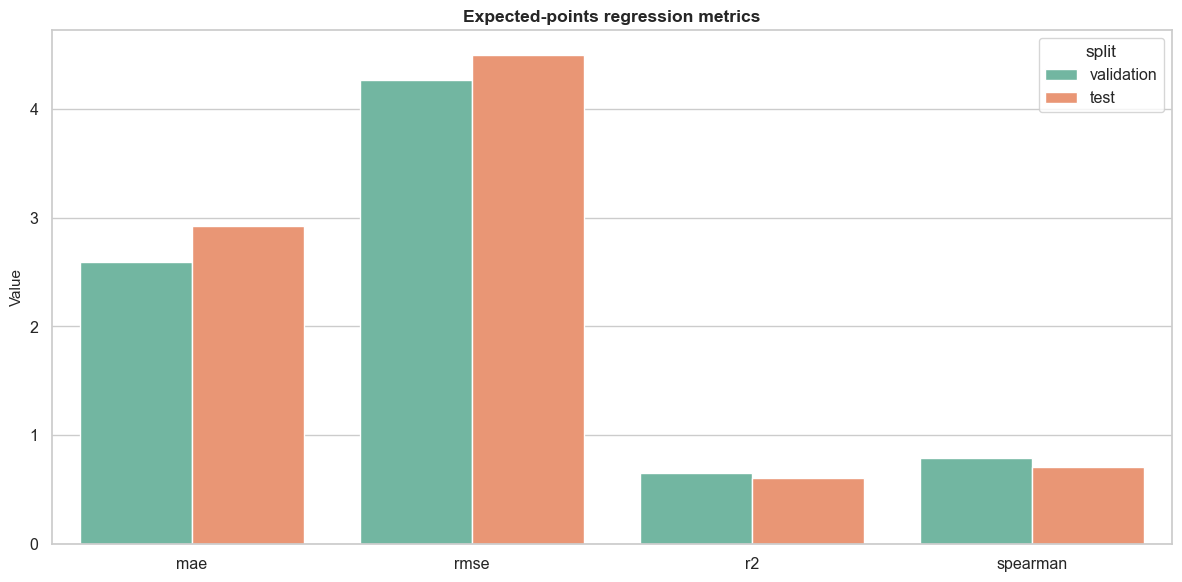

In [32]:
regression_records = []
for split_name, values in points_metrics.items():
    for metric_name, value in values.items():
        regression_records.append({"split": split_name, "metric": metric_name, "value": value})

regression_metric_df = pd.DataFrame(regression_records)

ax = sns.barplot(data=regression_metric_df, x="metric", y="value", hue="split")
ax.set_title("Expected-points regression metrics")
ax.set_xlabel("")
ax.set_ylabel("Value")
plt.tight_layout()
plt.show()

### confusion_matrix_top10_test.png

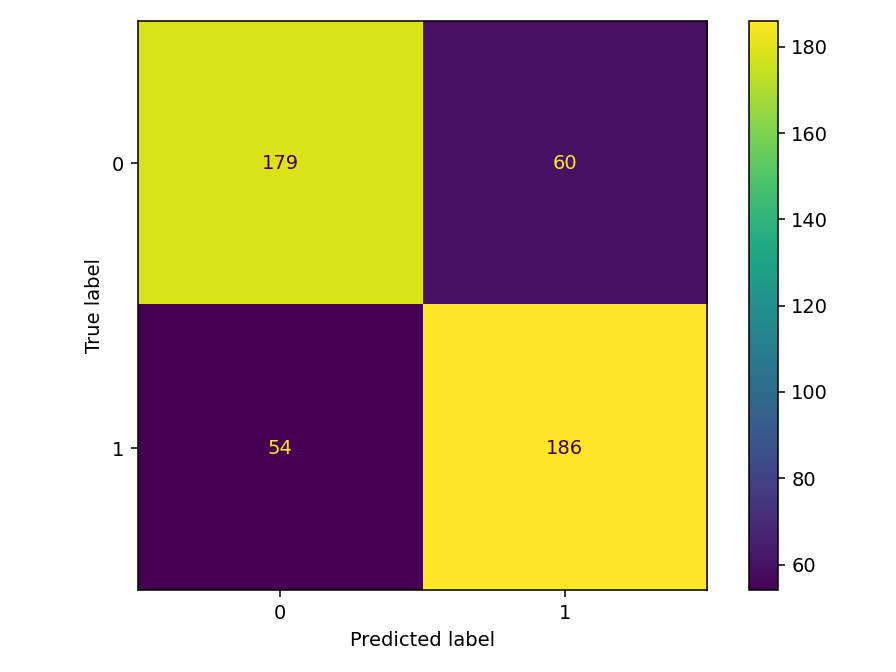

### confusion_matrix_podium_test.png

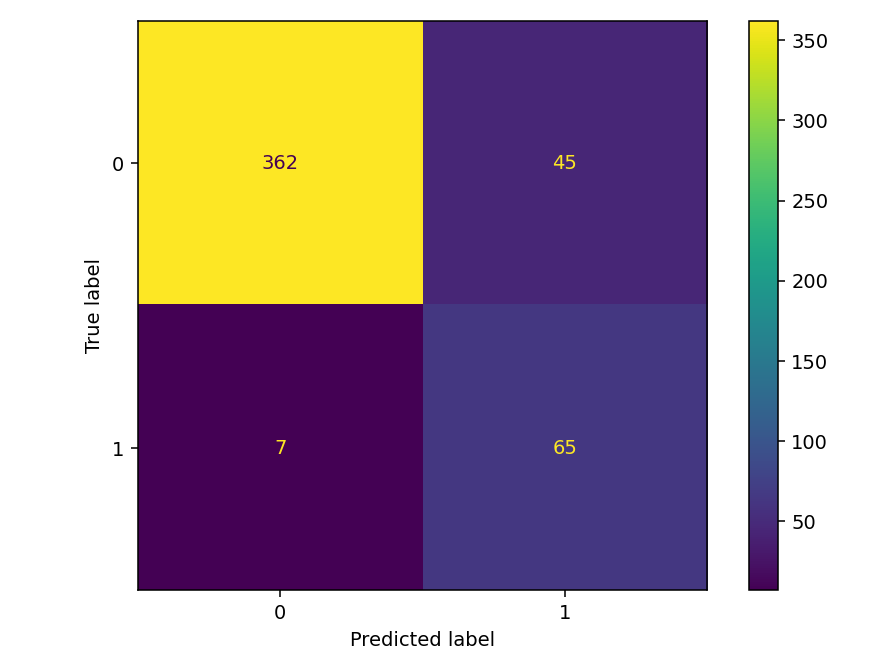

### roc_top10_test.png

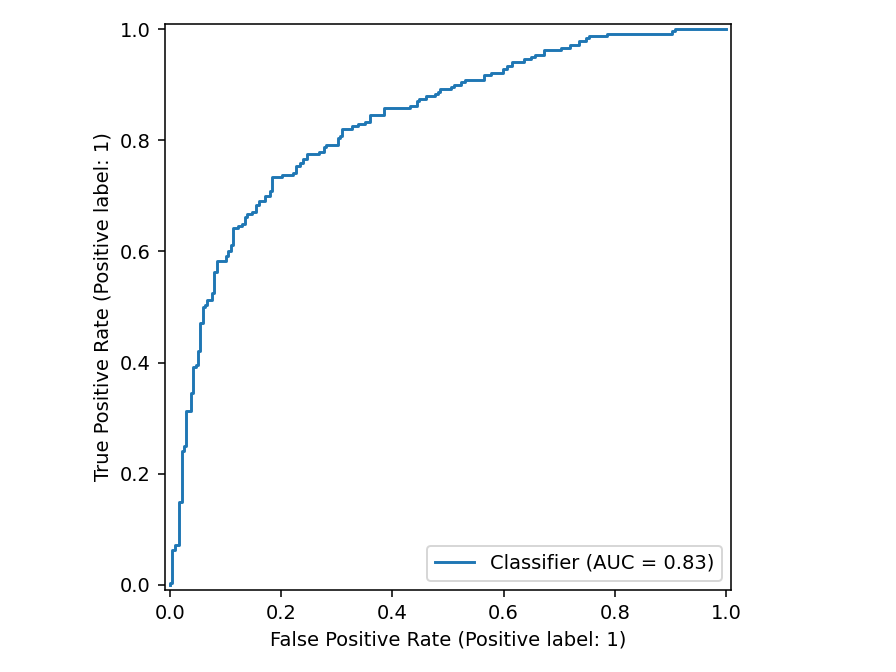

### roc_podium_test.png

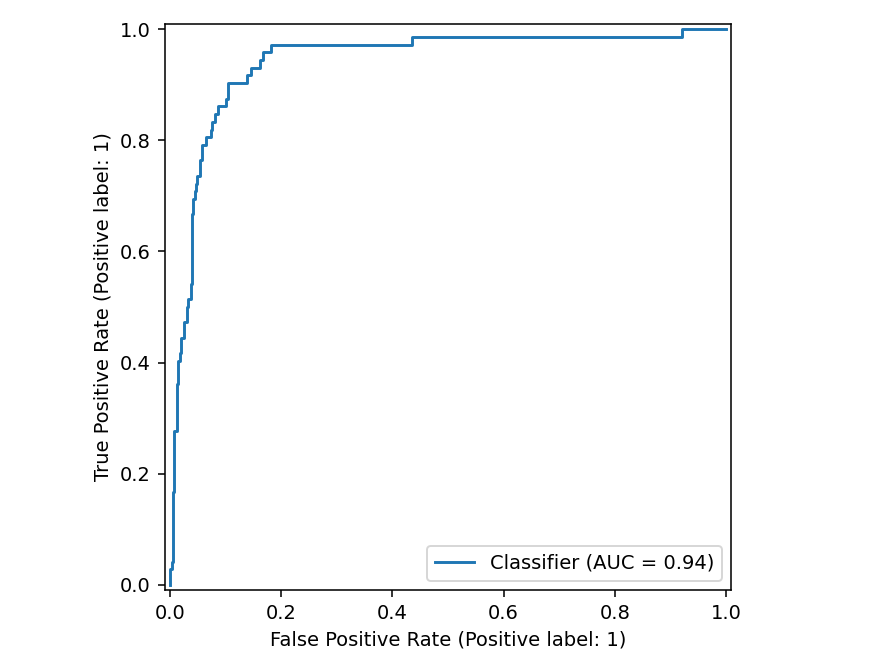

### precision_recall_podium_test.png

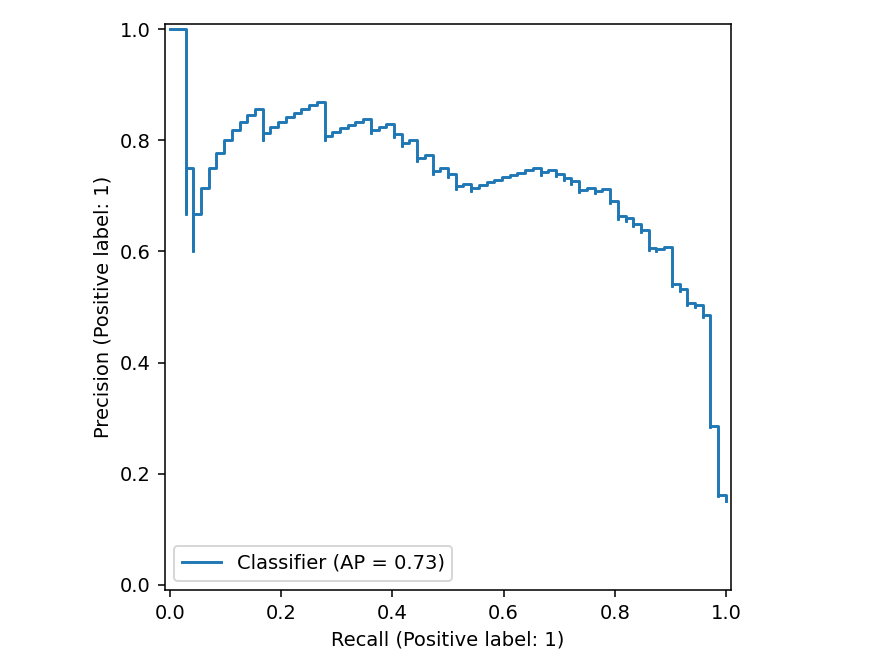

### predicted_vs_actual_points_test.png

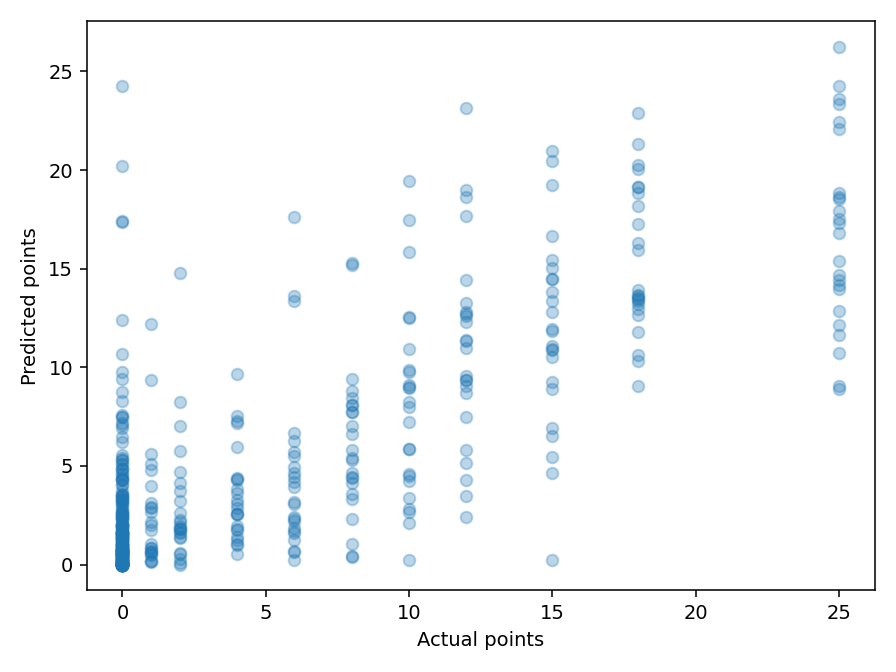

In [33]:
figures_dir = paths["reports"] / "figures"

figure_files = [
    "confusion_matrix_top10_test.png",
    "confusion_matrix_podium_test.png",
    "roc_top10_test.png",
    "roc_podium_test.png",
    "precision_recall_podium_test.png",
    "predicted_vs_actual_points_test.png",
]

for file_name in figure_files:
    path = figures_dir / file_name
    if path.exists():
        display(Markdown(f"### {file_name}"))
        display(Image(filename=str(path)))

# Feature Importance

Feature importance helps explain which variables the trained models rely on most. These charts come from the fitted model artifacts.

### feature_importance_top10.png

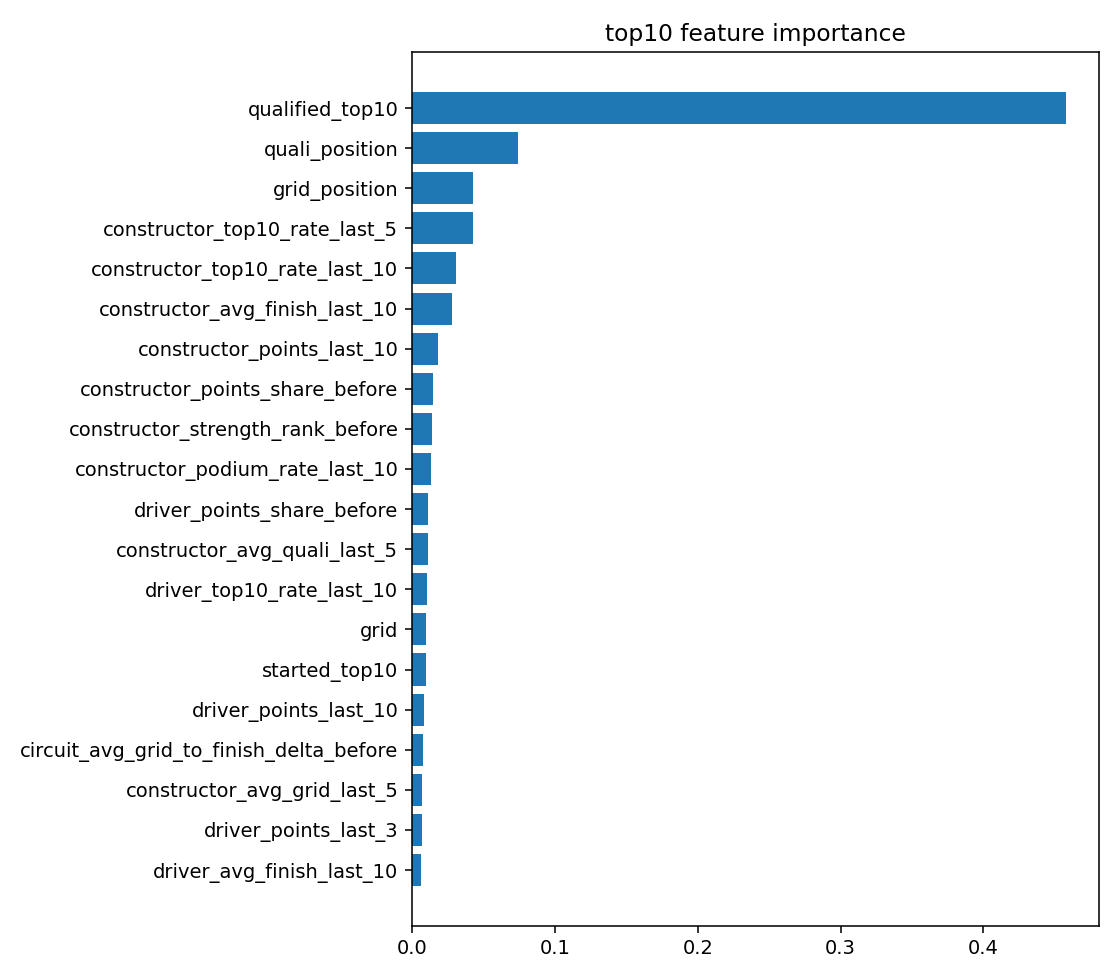

### feature_importance_podium.png

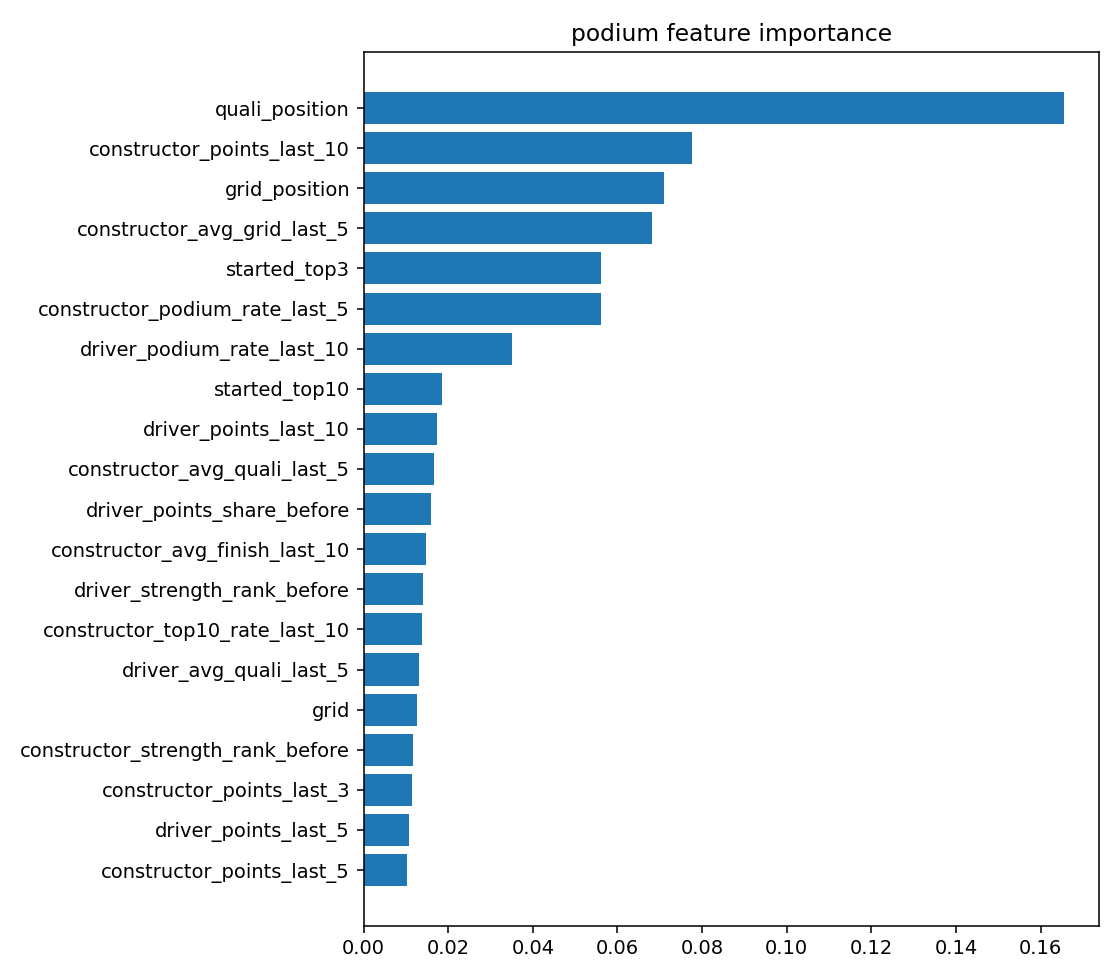

### feature_importance_points.png

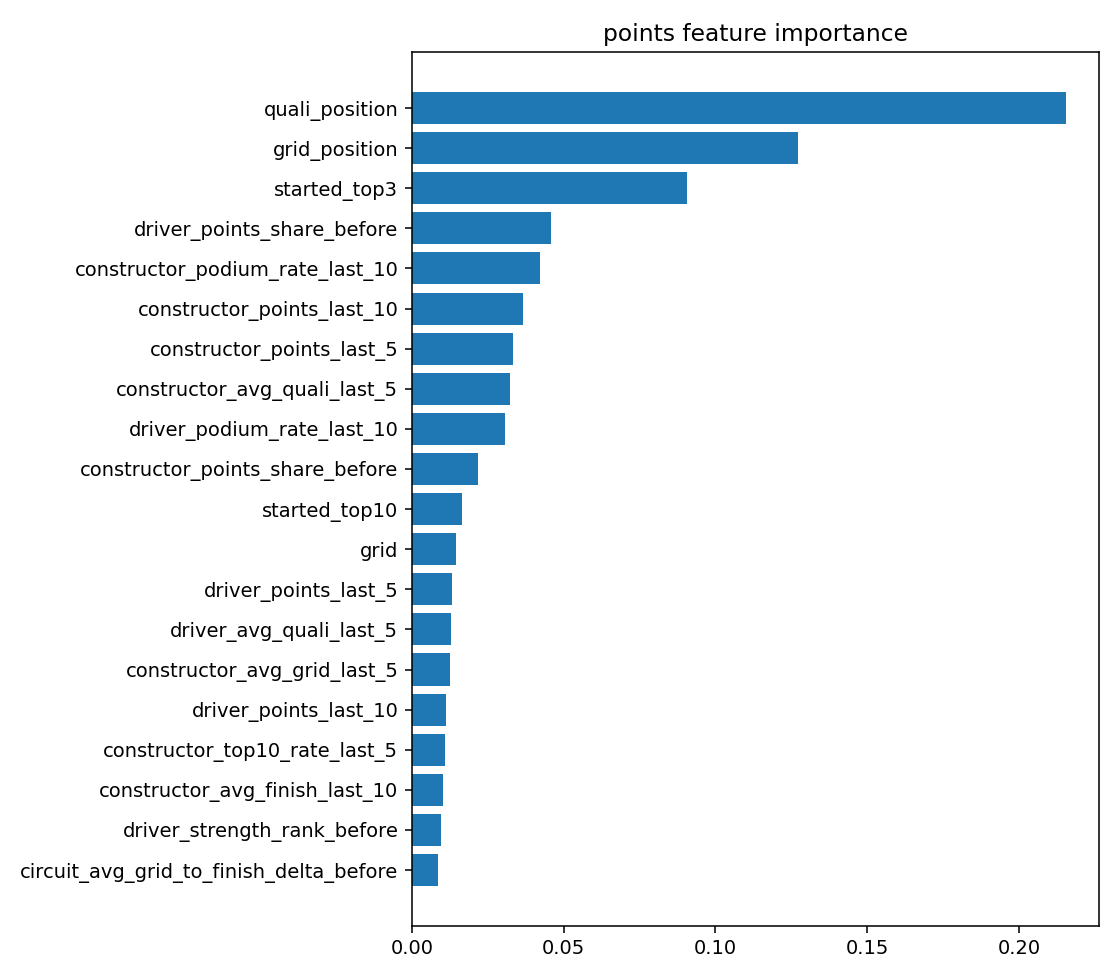

In [34]:
for file_name in [
    "feature_importance_top10.png",
    "feature_importance_podium.png",
    "feature_importance_points.png",
]:
    path = figures_dir / file_name
    if path.exists():
        display(Markdown(f"### {file_name}"))
        display(Image(filename=str(path)))

,feature,importance,task
0,qualified_top10,0.457934,top10
1,quali_position,0.074546,top10
2,grid_position,0.042769,top10
3,constructor_top10_rate_last_5,0.042504,top10
4,constructor_top10_rate_last_10,0.030606,top10
5,constructor_avg_finish_last_10,0.027936,top10
6,constructor_points_last_10,0.018167,top10
7,constructor_points_share_before,0.014774,top10
8,constructor_strength_rank_before,0.014158,top10
9,constructor_podium_rate_last_10,0.013211,top10


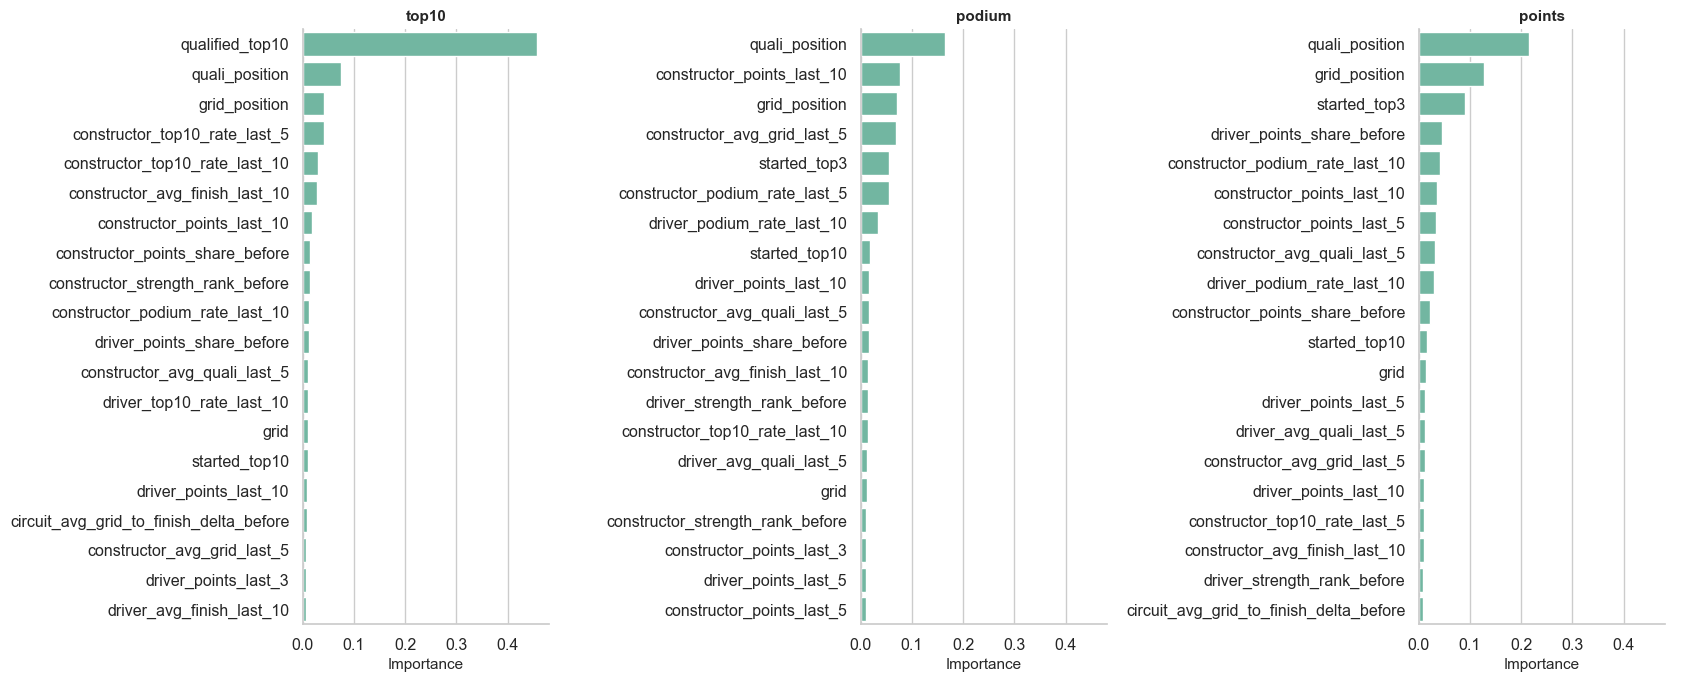

In [35]:
importance_frames = []
for task_name, model in models.items():
    values = getattr(model, "feature_importances_", None)
    if values is not None and saved_features:
        tmp = pd.DataFrame({
            "feature": saved_features,
            "importance": values,
            "task": task_name,
        }).sort_values("importance", ascending=False).head(20)
        importance_frames.append(tmp)

if importance_frames:
    importance_df = pd.concat(importance_frames, ignore_index=True)
    display(importance_df)

    g = sns.catplot(
        data=importance_df,
        y="feature",
        x="importance",
        col="task",
        kind="bar",
        sharey=False,
        height=7,
        aspect=0.8,
    )
    g.set_titles("{col_name}")
    g.set_axis_labels("Importance", "")
    plt.tight_layout()
    plt.show()

# Baseline Comparison

Baselines are important because Formula 1 is highly grid-dependent. A model must be compared against simple grid- and qualifying-based heuristics.

,split,task,baseline,f1,roc_auc,accuracy
0,validation,top10,grid_top10,0.837500,0.837160,0.837161
1,validation,top10,quali_top10,0.850000,0.849686,0.849687
2,validation,podium,grid_podium,0.666667,0.803849,0.899791
3,validation,podium,quali_podium,0.625000,0.779330,0.887265
4,test,top10,grid_top10,0.779167,0.778705,0.778706
5,test,top10,quali_top10,0.779167,0.778705,0.778706
6,test,podium,grid_podium,0.750000,0.852887,0.924843
7,test,podium,quali_podium,0.750000,0.852887,0.924843


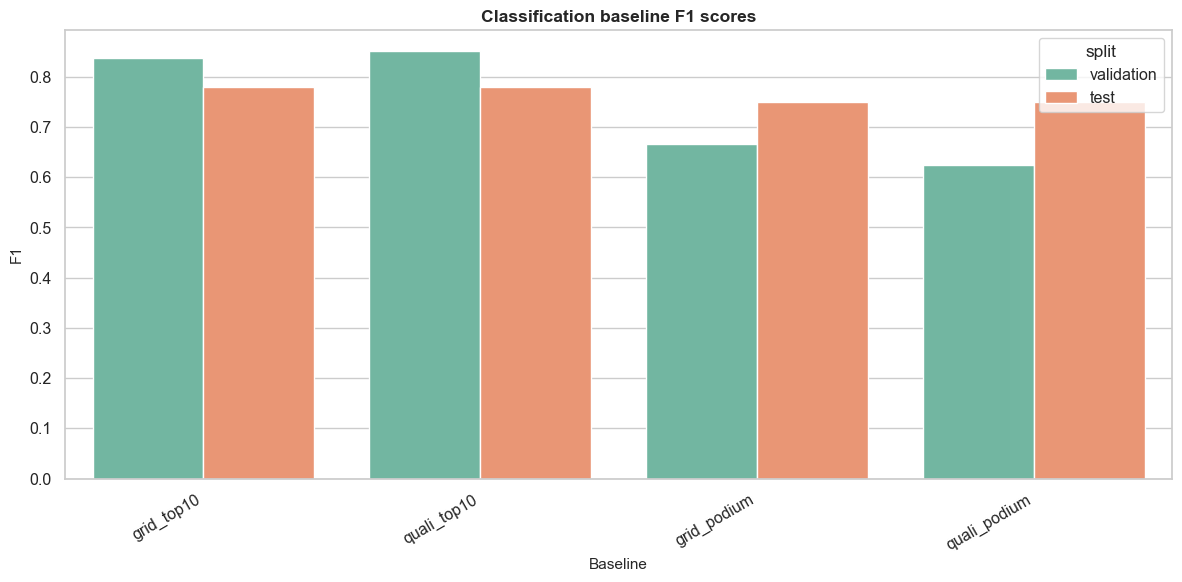

In [36]:
baseline_records = []
for split_name, split_values in baseline_metrics.items():
    for task_name in ["top10", "podium"]:
        for baseline_name, metric_values in split_values.get(task_name, {}).items():
            baseline_records.append({
                "split": split_name,
                "task": task_name,
                "baseline": baseline_name,
                "f1": metric_values.get("f1"),
                "roc_auc": metric_values.get("roc_auc"),
                "accuracy": metric_values.get("accuracy"),
            })

baseline_df = pd.DataFrame(baseline_records)
display(baseline_df)

if not baseline_df.empty:
    ax = sns.barplot(data=baseline_df, x="baseline", y="f1", hue="split")
    ax.set_title("Classification baseline F1 scores")
    ax.set_xlabel("Baseline")
    ax.set_ylabel("F1")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

# 2026 Live Predictions

The prediction layer exports dashboard-ready CSV files. The notebook checks whether probabilities are valid and visualizes the live/application predictions.

In [37]:
prediction_dir = paths["predictions"]
combined_prediction_path = prediction_dir / "2026_combined_predictions.csv"
missing_inputs_path = prediction_dir / "2026_missing_inputs.csv"

pred_2026 = pd.read_csv(combined_prediction_path) if combined_prediction_path.exists() else pd.DataFrame()
missing_2026 = pd.read_csv(missing_inputs_path) if missing_inputs_path.exists() else pd.DataFrame()

print(f"2026 predictions shape: {pred_2026.shape}")
print(f"2026 missing inputs shape: {missing_2026.shape}")

display(pred_2026.head())
display(missing_2026.head())

2026 predictions shape: (195, 13)
2026 missing inputs shape: (3, 8)


,season,round,raceName,date,driver_name,constructor_name,grid,quali_position,proba_top10,proba_podium,expected_points,predicted_top10,predicted_podium
0,2026,1,Australian Grand Prix,2026-03-08,Lewis Hamilton,Ferrari,7.0,7.0,0.805012,0.127155,6.471503,1,0
1,2026,1,Australian Grand Prix,2026-03-08,Fernando Alonso,Aston Martin,17.0,17.0,0.112824,0.009130,0.563964,0,0
2,2026,1,Australian Grand Prix,2026-03-08,Nico Hülkenberg,Audi,11.0,11.0,0.611661,0.008961,2.450465,1,0
3,2026,1,Australian Grand Prix,2026-03-08,Sergio Pérez,Cadillac F1 Team,18.0,18.0,0.249726,0.023666,1.506428,0,0
4,2026,1,Australian Grand Prix,2026-03-08,Valtteri Bottas,Cadillac F1 Team,19.0,19.0,0.139165,0.004962,0.848995,0,0


,season,round,raceName,date,driver_name,constructor_name,grid,quali_position
0,2026,1,Australian Grand Prix,2026-03-08,Max Verstappen,Red Bull,20.0,NaN
1,2026,1,Australian Grand Prix,2026-03-08,Carlos Sainz,Williams,21.0,NaN
2,2026,1,Australian Grand Prix,2026-03-08,Lance Stroll,Aston Martin,22.0,NaN


In [38]:
if not pred_2026.empty:
    checks = {
        "top10_probability_valid": pred_2026["proba_top10"].between(0, 1).all(),
        "podium_probability_valid": pred_2026["proba_podium"].between(0, 1).all(),
        "expected_points_non_negative": pred_2026["expected_points"].ge(0).all(),
    }
    display(pd.Series(checks).to_frame("passed"))

,passed
top10_probability_valid,True
podium_probability_valid,True
expected_points_non_negative,True


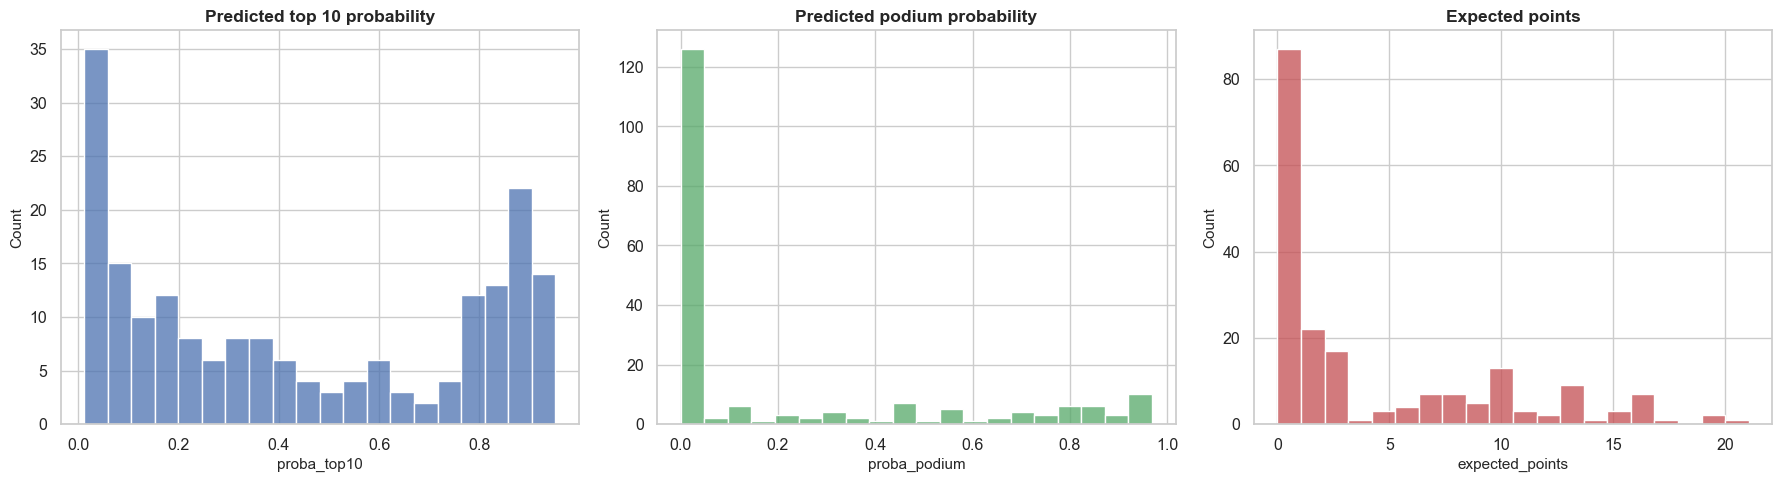

In [39]:
if not pred_2026.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.histplot(pred_2026["proba_top10"], bins=20, ax=axes[0], color="#4C72B0")
    axes[0].set_title("Predicted top 10 probability")

    sns.histplot(pred_2026["proba_podium"], bins=20, ax=axes[1], color="#55A868")
    axes[1].set_title("Predicted podium probability")

    sns.histplot(pred_2026["expected_points"], bins=20, ax=axes[2], color="#C44E52")
    axes[2].set_title("Expected points")

    plt.tight_layout()
    plt.show()

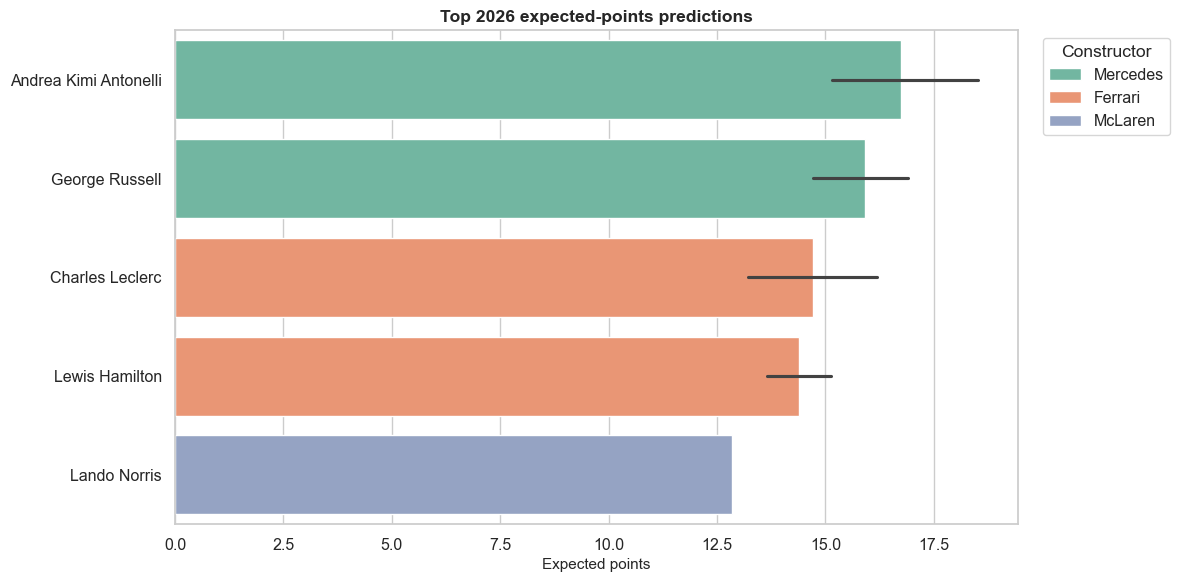

In [40]:
if not pred_2026.empty:
    top_expected_points = (
        pred_2026.sort_values("expected_points", ascending=False)
        .head(20)
        .copy()
    )

    ax = sns.barplot(data=top_expected_points, y="driver_name", x="expected_points", hue="constructor_name", dodge=False)
    ax.set_title("Top 2026 expected-points predictions")
    ax.set_xlabel("Expected points")
    ax.set_ylabel("")
    plt.legend(title="Constructor", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

,round,raceName,drivers,avg_top10_probability,avg_podium_probability,total_expected_points
0,1,Australian Grand Prix,19,0.480701,0.211633,83.210263
1,2,Chinese Grand Prix,22,0.407623,0.172262,90.603179
2,3,Japanese Grand Prix,22,0.391078,0.198550,90.442280
3,4,Miami Grand Prix,22,0.383163,0.216874,93.960546
4,5,Canadian Grand Prix,22,0.404513,0.186928,83.728696
5,6,Monaco Grand Prix,22,0.476375,0.234794,100.498586
6,7,Barcelona Grand Prix,22,0.445966,0.207018,93.723385
7,8,Austrian Grand Prix,22,0.483106,0.238698,111.023944
8,9,British Grand Prix,22,0.445952,0.214408,100.733390


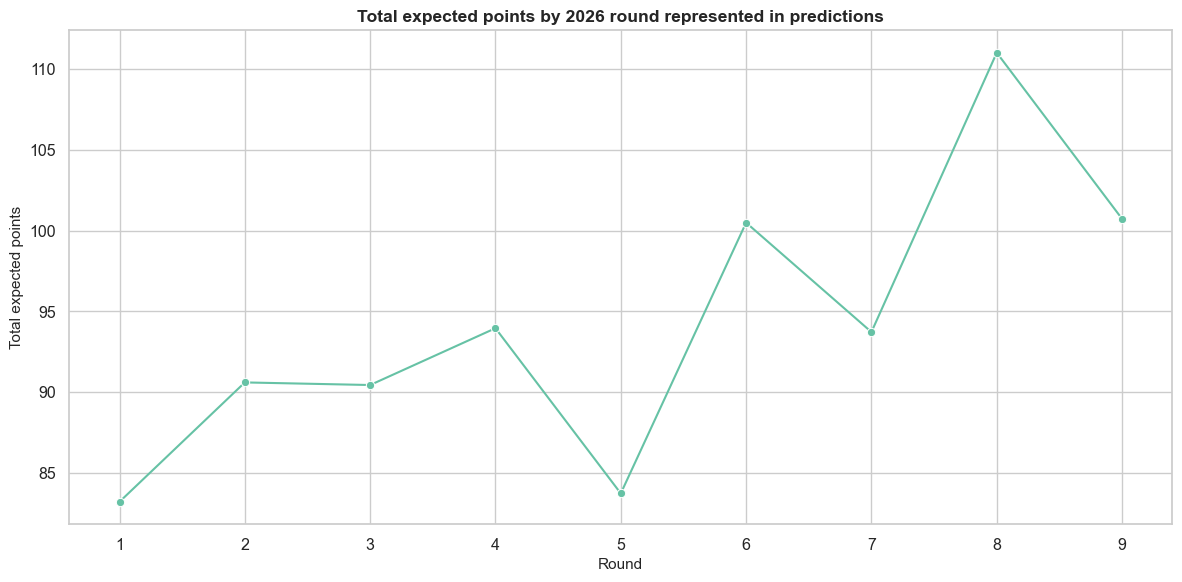

In [41]:
if not pred_2026.empty:
    round_summary = (
        pred_2026.groupby(["round", "raceName"])
        .agg(
            drivers=("driver_name", "count"),
            avg_top10_probability=("proba_top10", "mean"),
            avg_podium_probability=("proba_podium", "mean"),
            total_expected_points=("expected_points", "sum"),
        )
        .reset_index()
    )

    display(round_summary)

    ax = sns.lineplot(data=round_summary, x="round", y="total_expected_points", marker="o")
    ax.set_title("Total expected points by 2026 round represented in predictions")
    ax.set_xlabel("Round")
    ax.set_ylabel("Total expected points")
    plt.tight_layout()
    plt.show()

# Risks, Limitations, and Next Steps

This V1 is intentionally focused and reproducible. It does not use weather, tire strategy, detailed telemetry, safety-car context, or free-practice pace.

The main current limitation is 2026 coverage: the Jolpica 2026 schedule contains future races, but the driver-race prediction table only contains rounds with available driver-level result/qualification rows. Future schedule-only races should be exported as missing application inputs instead of being silently absent.

In [42]:
audit_notes = []

train_seasons = set(parts["train"]["season"].unique())
if 2026 in train_seasons:
    audit_notes.append("2026 appears in the training split.")
else:
    audit_notes.append("PASS: 2026 is not used in the default training split.")

if 2025 in train_seasons:
    audit_notes.append("2025 appears in the training split.")
else:
    audit_notes.append("PASS: 2025 is reserved for official testing.")

if schedule_2026_path.exists():
    missing_schedule_rounds = schedule_2026.loc[~schedule_2026["in_final_dataset"], ["round", "raceName", "date"]]
    audit_notes.append(f"2026 schedule rounds absent from final dataset: {len(missing_schedule_rounds)}")
    display(missing_schedule_rounds)

for note in audit_notes:
    print(note)

,round,raceName,date
9,10,Belgian Grand Prix,2026-07-19
10,11,Hungarian Grand Prix,2026-07-26
11,12,Dutch Grand Prix,2026-08-23
12,13,Italian Grand Prix,2026-09-06
13,14,Spanish Grand Prix,2026-09-13
14,15,Azerbaijan Grand Prix,2026-09-26
15,16,Singapore Grand Prix,2026-10-11
16,17,United States Grand Prix,2026-10-25
17,18,Mexico City Grand Prix,2026-11-01
18,19,Brazilian Grand Prix,2026-11-08


PASS: 2026 is not used in the default training split.
PASS: 2025 is reserved for official testing.
2026 schedule rounds absent from final dataset: 13


# Final Summary

The project now has a single notebook that follows a portfolio-style data science structure:

1. project initialization;
2. data loading and audit;
3. exploratory data analysis;
4. feature engineering explanation;
5. temporal split;
6. model artifacts;
7. metrics and figures;
8. feature importance;
9. baseline comparison;
10. 2026 live predictions;
11. limitations and next steps.

The notebook is meant to be read from top to bottom and used as the main presentation artifact for the V1.